In [140]:
import pandas as pd
import numpy as np


In [ ]:
#!pip install -U keras-tuner
#!pip install sklearn

In [142]:
import tensorflow as tf
from tensorflow import keras
import os
import matplotlib.pyplot as plt
#from kerastuner.engine import TrialStatus
from keras_tuner import errors

In [143]:
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.callbacks import TerminateOnNaN

In [144]:
%tensorflow_version 2.x
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from kerastuner.tuners import RandomSearch, Hyperband, BayesianOptimization
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from google.colab import files
import keras_tuner as kt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [145]:
# from google.colab import drive
# drive.mount('/drive')

In [146]:
# from google.colab import drive
# drive.mount('/content/drive')

In [147]:
def load_config(filename):
  f = open(filename)
  d = {}
  for row in f:
    if row[0] == '#': continue
    k = row.find('=')
    if k > 0:
      d[row[:k]] = row[k+1:].rstrip()
  return d

In [148]:
config_file = 'data.cfg'
# config_file = 'dataregr.cfg'
# config_file = 'data2.cfg'

settings_dict = load_config(config_file)
settings_dict

{'directory': 'data',
 'fields': ' Code::Int64==Code&& Dish==Dish&& Quantity==Quantity&& Wed price==Wed price&& Sum==Sum&& Discount==Discount',
 'index_field': 'Code',
 'skiprows': '2',
 'skipfooter': '0',
 'aggregate': 'Dish::last&&Quantity::sum&&Wed price::mean&&Sum::sum&&Discount::sum',
 'y_name': 'Quantity',
 'x_fields': 'Quantity&&Wed price&&Sum&&Discount',
 'pred_fields': 'Quantity&&Sum',
 'show_fields': 'Dish',
 'epoch_count': '500',
 'batch_size': '256',
 'patience_count': '10',
 'lag': '6',
 'forecast_size': '1',
 'sort_expression': '(\\d{4})',
 'sort_pattern': '(\\d\\d)(\\d\\d)',
 'sort_repl': '\\2\\1'}

In [149]:
def get_settings(settings_dict, field, default_val=None):
  # print('---', field, settings_dict)
  if field in settings_dict: return settings_dict.get(field)
  return default_val

def get_int_settings(settings_dict, field, default_val=None):
  val = get_settings(settings_dict, field, default_val=None)
  if val is None: return default_val
  return int(val)

def get_list_settings(settings_dict, field, sep=' ', default_val=None):
  val = get_settings(settings_dict, field, default_val=None)
  if val is None: return default_val
  return val.split(sep)

def get_bool_settings(settings_dict, field, default_val=None):
  val = get_settings(settings_dict, field, default_val=None)
  if val is None: return default_val
  return val.lower() in ['true', '1', 't', 'y', 'yes']

In [150]:
# x_fields = ['Quantity','Wed price', 'Sum', 'Discount']

pred_fields = get_list_settings(settings_dict, 'pred_fields', sep=get_settings(settings_dict, 'field_sep', '&&')) # ['Quantity', 'Sum']
show_fields = get_list_settings(settings_dict, 'show_fields', sep=get_settings(settings_dict, 'field_sep', '&&'), default_val=[])

epoch_count = get_int_settings(settings_dict, 'epoch_count', 500)
batch_size = get_int_settings(settings_dict, 'batch_size', 256)
patience_count = get_int_settings(settings_dict, 'patience_count', 10)

y_name = get_settings(settings_dict, 'y_name') # 'Quantity' # 'Sum' #'Quantity'

y_normalize = False # True
time_line_split = True

lag = get_int_settings(settings_dict, 'lag', 4)

sort_expression = get_settings(settings_dict, 'sort_expression', '\d{4}')
sort_pattern = get_settings(settings_dict, 'sort_pattern', '(\d\d)(\d\d)')
sort_repl = get_settings(settings_dict, 'sort_repl', '\\2\\1')

In [151]:
def load_meta_data(config):
  dtype_dict = {}
  alias_dict = {}
  cols = []
  aliased_cols = []
  for field in get_settings(config, 'fields', '').split(get_settings(config, 'field_sep', '&&')):
    lst = field.split(get_settings(config, 'alias_sep', '=='))
    lst2 = lst[0].split(get_settings(config, 'type_sep', '::'))
    fname = lst2[0]
    cols.append(fname)
    if len(lst)>1:
      alias_dict[fname] = lst[1]
      aliased_cols.append(lst[1])
    else:
      aliased_cols.append(lst[0])
    if len(lst2)>1:
      dtype_dict[fname] = lst2[1]
  # print('dtype:', dtype_dict)
  # print('cols:', cols)
  print('alias:', alias_dict)
  print('aliased_cols:', aliased_cols)
  index_field=get_settings(config, 'index_field', None)
  print('index_field:', index_field)

  aggr_str = get_settings(config, 'aggregate', None)
  print(f'aggr_str:<{aggr_str}>')
  aggr_cols = None
  if aggr_str is not None and len(aggr_str) > 0:
    aggr_cols = {}
    for field in aggr_str.split(get_settings(config, 'field_sep', '&&')):
      lst = field.split(get_settings(config, 'type_sep', '::'))
      aggr_cols[lst[0]] = lst[1]
  print('aggr_cols:', aggr_cols)

  x_fields = []
  x_fields_str = get_settings(config, 'x_fields', None)
  if x_fields_str is None:
    x_fields = [alias_dict.get(i, i) for i in cols]
  else:
    x_fields = x_fields_str.split(get_settings(config, 'field_sep', '&&'))
  print('x_fields:', x_fields)

  return [dtype_dict, alias_dict, cols, aliased_cols, index_field, aggr_cols, x_fields]

In [152]:
meta_data = load_meta_data(settings_dict)

x_fields = meta_data[6]
index_field = meta_data[4]

alias: {' Code': 'Code', ' Dish': 'Dish', ' Quantity': 'Quantity', ' Wed price': 'Wed price', ' Sum': 'Sum', ' Discount': 'Discount'}
aliased_cols: ['Code', 'Dish', 'Quantity', 'Wed price', 'Sum', 'Discount']
index_field: Code
aggr_str:<Dish::last&&Quantity::sum&&Wed price::mean&&Sum::sum&&Discount::sum>
aggr_cols: {'Dish': 'last', 'Quantity': 'sum', 'Wed price': 'mean', 'Sum': 'sum', 'Discount': 'sum'}
x_fields: ['Quantity', 'Wed price', 'Sum', 'Discount']


In [153]:
import pandas as pd

def load_csv_df(filename, meta_data, config):
  dtype_dict, alias_dict, cols, aliased_cols, index_field, aggr_cols, x_fields = meta_data
  csv_delimiter = get_settings(config, 'csv_delimiter', ',')
  df = pd.read_csv(filename, dtype=dtype_dict, usecols=cols, sep=csv_delimiter,
                     skiprows=get_int_settings(config, 'skiprows', 0),
                     skipfooter=get_int_settings(config, 'skipfooter', 0) )
  return df

In [154]:
def load_xls_df(filename, meta_data, config):
  dtype_dict, alias_dict, cols, aliased_cols, index_field, aggr_cols, x_fields = meta_data

  df = pd.read_excel(filename, dtype=dtype_dict, usecols=cols, engine='openpyxl',
                     skiprows=get_int_settings(config, 'skiprows', 0),
                     skipfooter=get_int_settings(config, 'skipfooter', 0))
  return df

In [155]:
def load_data(filename, find, meta_data, config):
  dtype_dict, alias_dict, cols, aliased_cols, index_field, aggr_cols, x_fields = meta_data

  ind = filename.rfind('.')
  ext = filename[ind+1:]
  if ext == 'csv':
    df = load_csv_df(filename, meta_data, config)
  else:
    df = load_xls_df(filename, meta_data, config)

  tcols = [alias_dict.get(i, i) for i in df.columns]
  df.columns = tcols
  drop_fields = [] + x_fields
  if index_field is not None: drop_fields.append(index_field)
  df.dropna(axis=0, inplace=True, ignore_index=False, subset=drop_fields)
  if index_field is not None:
    df.set_index(index_field, inplace=True)

  if aggr_cols is not None:
    df = df.groupby(level=df.index.names).agg(aggr_cols)

  d = {}
  for col in x_fields:
    d[col] = col + str(find)
  df.rename(columns=d, inplace=True)
  return df

In [156]:
tuner_config_file = 'tuner.cfg'

tuner_settings = load_config(tuner_config_file)
tuner_settings

{'max_trials_count': '10',
 'best_num_count': '5',
 'max_dense_count': '5',
 'min_neuron_count': '16',
 'max_neuron_count': '256',
 'step_neuron_count': '16',
 'aim_objective': 'val_mae',
 'aim_maximization': 'False',
 'aim_loss': 'mse',
 'choice_activation': 'relu&&sigmoid&&tanh&&elu&&selu',
 'choice_optimizer': 'adam&&rmsprop&&SGD',
 'choice_metrics': 'mae&&r2_score',
 'choice_batch_size': '256',
 'choice_epochs': '50'}

In [157]:
max_trials_count = get_int_settings(tuner_settings, 'max_trials_count', 10)
best_num_count = get_int_settings(tuner_settings, 'best_num_count', 5)

max_dense_count = get_int_settings(tuner_settings, 'max_dense_count', 5)
min_neuron_count = get_int_settings(tuner_settings, 'min_neuron_count', 16)
max_neuron_count = get_int_settings(tuner_settings, 'max_neuron_count', 256)
step_neuron_count = get_int_settings(tuner_settings, 'step_neuron_count', 16)

aim_objective = get_settings(tuner_settings, 'aim_objective', 'val_mae')
aim_maximization = get_bool_settings(tuner_settings, 'aim_maximization', 'False')
aim_loss = get_settings(tuner_settings, 'aim_loss', 'mse')
choice_activation = get_list_settings(tuner_settings, 'choice_activation',
                                      default_val=['relu', 'sigmoid', 'tanh', 'elu', 'selu'],
                                      sep=get_settings(settings_dict, 'field_sep', '&&'))
choice_optimizer = get_list_settings(tuner_settings, 'choice_optimizer',
                                     default_val=['adam','rmsprop','SGD'],
                                     sep=get_settings(settings_dict, 'field_sep', '&&'))
choice_metrics = get_list_settings(tuner_settings, 'choice_metrics',
                                   default_val=['mae', 'r2_score'],
                                   sep=get_settings(settings_dict, 'field_sep', '&&'))

choice_batch_size = get_int_settings(tuner_settings, 'choice_batch_size', 256)
choice_epochs = get_int_settings(tuner_settings, 'choice_epochs', 100)

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def show_best_metrics(tuner, X_val, y_val, tag="model"):
    model = tuner.get_best_models(1)[0]

    # prediction
    y_pred = model.predict(X_val, verbose=0)

    # metrics
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    r2  = r2_score(y_val, y_pred)

    print(f"[{tag}]  MSE: {mse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")


In [159]:
# choice_epochs=50 # 100
# choice_batch_size=256
#  new
class TSTuner(kt.RandomSearch):
    def run_trial(self, trial, X, y, n_splits=4,
                  epochs=choice_epochs, batch_size=choice_batch_size, callbacks=None, **kwargs):

        tscv = TimeSeriesSplit(n_splits=n_splits)
        valid_mae = []

        best_mae      = float("inf")
        best_weights  = None

        callbacksfull = [TerminateOnNaN()]
        if callbacks is not None: callbacksfull += callbacks

        for tr, val in tscv.split(X):
            model = self.hypermodel.build(trial.hyperparameters)
            model.fit(
                X[tr], y[tr],
                validation_data=(X[val], y[val]),
                epochs=epochs,
                batch_size=batch_size,
                verbose=0,
                callbacks=callbacksfull,
            )
            mae = model.history.history["val_mae"][-1]
            if not np.isnan(mae):
                valid_mae.append(float(mae))
                if mae < best_mae:
                    best_mae     = mae
                    best_weights = model.get_weights()

        if len(valid_mae) == 0:
            self.oracle.end_trial(trial.trial_id, status="INVALID")
            return {"val_mae": float("inf")}

        if best_weights is not None:
            model.set_weights(best_weights)

        mean_mae = float(np.mean(valid_mae))
        self.oracle.update_trial(
            trial.trial_id, metrics={"val_mae": mean_mae})
        self.save_model(trial.trial_id, model)
        return {"val_mae": mean_mae}

    def save_model(self, trial_id, model, **kw):
        path = os.path.join(self.project_dir, f"{trial_id}.keras")
        model.save(path, **kw)
        #fix so get model uses right derectory
    def load_model(self, trial):          # trial – object Trial
        trial_id = trial.trial_id
        path = os.path.join(self.project_dir, f"{trial_id}.keras")
        return keras.models.load_model(path)



In [160]:
import os
 #!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Path to directtory that is used if config (data.cfg file) doesnt specify that
directory = get_settings(settings_dict, 'directory', "data")

# get file list
files = os.listdir(directory)

# show file list
print(len(files))
print(files)

21
['0807-1407.xls.xlsx', '2309-3009.xls.xlsx', '2406-3006.xls.xlsx', '0605-1205.xls.xlsx', '1305-1905.xls.xlsx', '0109-0809.xls.xlsx', '0107-0707.xls.xlsx', '2508-3108.xls.xlsx', '2005-2605.xls.xlsx', '1808-2408.xls.xlsx', '1706-2306.xls.xlsx', '1108-1708.xls.xlsx', '1006-1606.xls.xlsx', '1609-2209.xls.xlsx', '2705-3105.xls.xlsx', '0106-0906.xls.xlsx', '0909-1509.xls.xlsx', '0105-0505.xls.xlsx', '0108-1008.xls.xlsx', '2207-2807.xls.xlsx', '1507-2107.xls.xlsx']


In [161]:
import re

def get_date_from_name(s):
  print(s)
  regex = re.search(sort_expression, s).group(1)
  res = re.sub(sort_pattern, sort_repl, regex)
  if len(res) == 0: return None
  return int(res)

# def get_date_from_name(s):
#   k = 0
#   while k < len(s) and s[k] not in '0123456789': k += 1
#   return s[k+2:k+4] + s[k:k+2]

arr = [(get_date_from_name(fn), fn) for fn in files]
arr = [i for i in arr if i[0] is not None]
fnames = [i[1] for i in sorted(arr)]
fnames

0807-1407.xls.xlsx
2309-3009.xls.xlsx
2406-3006.xls.xlsx
0605-1205.xls.xlsx
1305-1905.xls.xlsx
0109-0809.xls.xlsx
0107-0707.xls.xlsx
2508-3108.xls.xlsx
2005-2605.xls.xlsx
1808-2408.xls.xlsx
1706-2306.xls.xlsx
1108-1708.xls.xlsx
1006-1606.xls.xlsx
1609-2209.xls.xlsx
2705-3105.xls.xlsx
0106-0906.xls.xlsx
0909-1509.xls.xlsx
0105-0505.xls.xlsx
0108-1008.xls.xlsx
2207-2807.xls.xlsx
1507-2107.xls.xlsx


['0105-0505.xls.xlsx',
 '0605-1205.xls.xlsx',
 '1305-1905.xls.xlsx',
 '2005-2605.xls.xlsx',
 '2705-3105.xls.xlsx',
 '0106-0906.xls.xlsx',
 '1006-1606.xls.xlsx',
 '1706-2306.xls.xlsx',
 '2406-3006.xls.xlsx',
 '0107-0707.xls.xlsx',
 '0807-1407.xls.xlsx',
 '1507-2107.xls.xlsx',
 '2207-2807.xls.xlsx',
 '0108-1008.xls.xlsx',
 '1108-1708.xls.xlsx',
 '1808-2408.xls.xlsx',
 '2508-3108.xls.xlsx',
 '0109-0809.xls.xlsx',
 '0909-1509.xls.xlsx',
 '1609-2209.xls.xlsx',
 '2309-3009.xls.xlsx']

In [162]:


data = []
for i in range(len(fnames)):
  df = load_data(directory + '/' + fnames[i], i, meta_data, settings_dict)
  data.append(df)



In [163]:
ind = 0
print(fnames[ind])
data[ind]

0105-0505.xls.xlsx


,Dish,Quantity0,Wed price0,Sum0,Discount0
Code,,,,,
16,Sky Lounge Salad,2,720.0,1440,0.0
18,Salad with duck fillet and mozzarella,3,650.0,1950,0.0
22,Salad with crispy eggplant,6,420.0,2520,-168.0
29,Whole grain bread,7,3.0,21,-2.1
39,Caesar with chicken fillet and bacon,8,420.0,3360,-252.0
...,...,...,...,...,...
1848,Meatballs,1,140.0,140,0.0
1911,Baked vegetables,8,110.0,880,0.0
1935,Buckwheat porridge,16,80.0,1280,0.0


In [164]:
df = data[ind]

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numeric_cols = df.columns[df.dtypes.isin(numerics)]

for col in numeric_cols:
  q_low = df[col].quantile(0.25)
  q_hi = df[col].quantile(0.75)
  q_range = q_hi - q_low
  # tdf = df[((df[col] < q_hi + 1.5 * q_range) & (df[col] > q_low - 1.5 * q_range))]
  tdf = df[((df[col] >= q_hi + 1.5 * q_range) | (df[col] <= q_low - 1.5 * q_range))]
  print(tdf)
  print(col, df.shape, '==>', tdf.shape)


                                        Dish  Quantity0  Wed price0   Sum0  \
Code                                                                         
645       Pancakes with sauce of your choice         32       130.0   4160   
912                  Meat and cheese platter        102       130.0  13260   
920                     Vegetable assortment         72       100.0   7200   
926                         Fruit assortment         61        70.0   4270   
946                         Bread and butter         59        20.0   1180   
1157                              Fried eggs         54       100.0   5400   
1712   Minced pork with mushrooms and cheese         35       140.0   4900   

      Discount0  
Code             
645      -689.0  
912     -1904.5  
920     -1450.0  
926      -952.0  
946      -263.0  
1157     -615.0  
1712        0.0  
Quantity0 (101, 5) ==> (7, 5)
                                    Dish  Quantity0  Wed price0  Sum0  \
Code                            

In [165]:
# data = data[:10]

max_index = len(data)-1

In [166]:
df = data[0]
for i in range(1, len(data)):
  tdf = data[i][[col+str(i) for col in x_fields]]
  df = pd.merge(df, tdf, left_index=True, right_index=True)
  # del data[i]['Dish']
  # df = pd.merge(df, data[i], left_index=True, right_index=True)

print(df.shape)
df

(45, 85)


,Dish,Quantity0,Wed price0,Sum0,Discount0,Quantity1,Wed price1,Sum1,Discount1,Quantity2,...,Sum18,Discount18,Quantity19,Wed price19,Sum19,Discount19,Quantity20,Wed price20,Sum20,Discount20
Code,,,,,,,,,,,,,,,,,,,,,
16,Sky Lounge Salad,2,720.0,1440,0.0,6.0,720.0,4320,-504.0,5.0,...,38690.0,-1241.0,8.0,730.0,5840,-365.0,9.0,730.0,6570,-730.0
22,Salad with crispy eggplant,6,420.0,2520,-168.0,11.0,420.0,4620,-336.0,12.0,...,22000.0,-1595.0,20.0,550.0,11000,-1045.0,20.0,550.0,11000,-770.0
39,Caesar with chicken fillet and bacon,8,420.0,3360,-252.0,14.0,420.0,5880,-462.0,8.0,...,32330.0,-1431.0,16.0,530.0,8480,-795.0,15.0,530.0,7950,-424.0
67,Kubete,8,120.0,960,-72.0,10.0,120.0,1200,-168.0,5.0,...,8760.0,-1574.4,59.0,120.0,7080,-1878.0,63.0,120.0,7560,-1068.0
88,Chicken liver pate with toast,1,390.0,390,-39.0,12.0,390.0,4680,-390.0,5.0,...,13760.0,-645.0,1.0,430.0,430,-43.0,3.0,430.0,1290,-129.0
109,Black Sea mussels with tomatoes,4,570.0,2280,-57.0,2.0,570.0,1140,-114.0,6.0,...,19950.0,-741.0,9.0,570.0,5130,-399.0,15.0,570.0,8550,-285.0
118,Pork shashlik,3,580.0,1740,-174.0,18.0,580.0,10440,-1044.0,7.0,...,37800.0,-1020.0,30.0,600.0,18000,-1560.0,8.0,600.0,4800,-360.0
119,Lamb shashlik,6,850.0,5100,0.0,4.0,850.0,3400,-340.0,2.0,...,34710.0,-445.0,1.0,890.0,890,-89.0,4.0,890.0,3560,-178.0
120,Chicken fillet shashlik,2,490.0,980,-49.0,2.0,490.0,980,-98.0,5.0,...,17680.0,-468.0,10.0,520.0,5200,-364.0,2.0,520.0,1040,-104.0


In [167]:
# tt = df[['Quantity'+str(i) for i in range(21)]]
# print(tt.shape)
# tt.mean(axis=0).mean(axis=0)

In [168]:
norm_d = {}

cols = set(pred_fields + [y_name])
for col in cols:
  arr = []
  for i in range(len(data)):
    arr.extend(df[col + str(i)])
  arr = np.array(arr)
  x_mean = arr.mean(axis=0)
  #x_std = arr.std(axis=0)
  x_std = arr.std()
  if x_std < 1e-8:
        x_std = 1.0
  norm_d[col] = (x_mean, x_std)

norm_d

{'Sum': (np.float64(11818.367195767196), np.float64(16012.458834069997)),
 'Quantity': (np.float64(79.05862433862433), np.float64(163.27423975452993))}

In [169]:
# df.loc[1744]

In [170]:
x_cluster = df.to_numpy()[:, 1:]

x_cluster.shape

(45, 84)

Neural Network (NN)

In [171]:
x = np.empty((0, len(pred_fields)*lag))
y = np.empty((0, 1))

for i in range(lag, len(data)):
  cols = []
  for j in range(i-lag, i):
    cols += [col + str(j) for col in pred_fields]
  # print(cols, y_name + str(i))
  x = np.append(x, df[cols].to_numpy(), 0)
  y = np.append(y, df[[y_name + str(i)]].to_numpy(), 0)

print(x.mean(axis=0))
print(x.std(axis=0))

for i in range(len(pred_fields)):
  x_mean, x_std = norm_d[pred_fields[i]]
  if x_std < 1e-8:
        continue
  for j in range(lag):
    x[:,j*len(pred_fields)+i] -= x_mean
    x[:,j*len(pred_fields)+i] /= x_std

print(x.mean(axis=0))
print(x.std(axis=0))

print(x.shape)
print(y.shape)

[   74.13244444 11291.42814815    80.84651852 12339.39555556
    85.62577778 13056.49777778    90.92651852 13810.2562963
    96.27022222 14671.65777778   100.4242963  15154.6162963 ]
[  157.81980592 15648.1371751    165.8516868  16308.01683823
   171.89076735 16726.05613051   177.31737654 17065.73720701
   182.09673649 17392.32963374   185.57561718 17557.16184841]
[-0.0301712  -0.03290807  0.01095025  0.03253894  0.04022161  0.07732295
  0.07268687  0.1243962   0.10541527  0.17819191  0.13085758  0.20835333]
[0.96659342 0.97724761 1.015786   1.018458   1.05277334 1.04456513
 1.08600951 1.06577868 1.11528148 1.08617482 1.13658846 1.09646882]
(675, 12)
(675, 1)


In [172]:
print(y.mean())
print(y.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y -= y_mean
  y /= y_std

  print(y.mean())
  print(y.std())

98.6962962962963
184.6072136174963


In [173]:
def prnXYSize(X, Y):
  col = X[0].size
  row = X.size // col
  return '(' + str(X.shape) + ', ' + str(col) + '),  ' + str(Y.size)

In [174]:
src_x_NN, src_y_NN = x, y

print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)


In [175]:
row_count = len(y) // (len(data) - lag)

# x_train = x[:-row_count, :]
# x_test = x[-row_count:, :]
# y_train = y[:-row_count]
# y_test = y[-row_count:]

In [176]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/(len(data) - lag), random_state=42)

# print(x_train)
# print(y_train)
# print(x_test)
# print(y_test)

In [177]:
print(x_train.shape)
print(x_test.shape)

(630, 12)
(45, 12)


In [178]:
row1 = 0
row2 = 10
tt = x_train[row1:row2, :]
tt

array([[-1.28977017e-01, -3.75855280e-01, -3.49464952e-01,
        -6.00680214e-01, -1.77974336e-01, -4.25816376e-01,
        -1.22852352e-01, -3.69610143e-01, -3.09823788e-02,
        -2.75933087e-01, -1.22852352e-01, -3.69610143e-01],
       [-3.61714282e-01, -6.13170488e-01, -1.71849671e-01,
        -4.19571239e-01, -4.22960930e-01, -6.75621858e-01,
        -3.18841628e-01, -5.69454529e-01, -4.22960930e-01,
        -6.75621858e-01, -5.54810382e-02, -3.00913635e-01],
       [-3.00467633e-01, -5.50719117e-01, -1.71849671e-01,
        -4.19571239e-01, -1.59600341e-01, -4.07080965e-01,
        -2.39220984e-01, -4.88267747e-01, -1.53475676e-01,
        -4.00835828e-01, -8.61043626e-02, -3.32139320e-01],
       [ 3.94392512e+00,  2.42259063e+00,  4.82587686e+00,
         3.05210045e+00,  4.47677096e+00,  2.80291948e+00,
         3.82143182e+00,  2.33515872e+00,  3.45395193e+00,
         2.07286296e+00,  3.33145863e+00,  1.98543104e+00],
       [ 2.50462888e+00, -1.28547852e-01,  3.1477186

In [179]:
tt = y_train[row1:row2, :]
tt

array([[ 44.],
       [ 37.],
       [ 71.],
       [620.],
       [912.],
       [ 15.],
       [ 60.],
       [718.],
       [  4.],
       [ 36.]])

In [180]:
def createNN(params=None):
  if params is not None:
    tuner = params[0]
    hp = params[1]
    model = tuner.hypermodel.build(hp)
    return model
  # Create Basic Deep neural network
  model = Sequential()
  model.add(Dense(64, activation='relu', input_shape=(x.shape[1],)))
  model.add(Dense(16, activation='relu'))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])
  return model

model = createNN()
model.summary() # print model architecture

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_254"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_866 (Dense)               │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_867 (Dense)               │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_868 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,889 (7.38 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

In [181]:
def build_NN(hp=None):
  if hp is None: return createNN()

  model = Sequential()
  activation_choice = hp.Choice('activation', values=choice_activation)
  dense_count = hp.Int('dense_count', min_value=2, max_value=max_dense_count, step=1)

  model.add(Dense(units=hp.Int('units_input', # connected layer with different amount of neurons
    min_value=min_neuron_count, # minimum amount of neurons
    max_value=max_neuron_count, # maximum amount of neurons
    step=step_neuron_count),
    input_dim=x_tuner_train.shape[1],
    activation=activation_choice))

  for i in range(2, max_dense_count + 1):
    units_cnt = hp.Int(
        f"units_hidden{i}",
        min_value=min_neuron_count,
        max_value=max_neuron_count,
        step=step_neuron_count
    )

    if i <= dense_count:
        model.add(Dense(units=units_cnt, activation=activation_choice))

#  for i in range(2, max_dense_count+1):
#    units_cnt = hp.Int('units_hidden' + str(i),
#      min_value=min_neuron_count,
#      max_value=max_neuron_count,
#      step=step_neuron_count),
#    # print(units_cnt)
#    if i <= dense_count:
#      model.add(Dense(units=units_cnt[0], activation=activation_choice))

  model.add(Dense(1))

  model.compile(
    optimizer=hp.Choice('optimizer', values=choice_optimizer),
      loss=aim_loss,
      metrics=choice_metrics)
  return model

# new fix for input layer error
def make_build_NN(input_dim):
    """
    Return function build_NN, that knows input dimension.
    """
    def build_NN_dynamic(hp):
        act  = hp.Choice("activation", values=choice_activation)
        dcnt = hp.Int("dense_count", 2, max_dense_count)

        model = Sequential()
        model.add(keras.Input(shape=(input_dim,)))
        model.add(Dense(
            units=hp.Int("units_input",
                         min_neuron_count, max_neuron_count,
                         step=step_neuron_count),
            activation=act))

        for i in range(2, dcnt + 1):
            model.add(Dense(
                units=hp.Int(f"units_hidden{i}",
                             min_neuron_count, max_neuron_count,
                             step=step_neuron_count),
                activation=act))

        model.add(Dense(1))
        model.compile(
            optimizer=hp.Choice("optimizer", values=choice_optimizer),
            loss="mse",
            metrics=["mae"])
        return model

    return build_NN_dynamic

In [182]:
x_tuner_train, y_tuner_train, x_tuner_test, y_tuner_test = x_train, y_train, x_test, y_test

In [183]:
from keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(monitor='val_mae', mode='min', min_delta=0.01, patience=patience_count)

# Start training of NN
history = model.fit(x_train, y_train, batch_size=256, epochs=epoch_count, verbose=2, validation_data=(x_test, y_test), callbacks=[early_stopping_callback])

print("Training stopped on epoch", early_stopping_callback.stopped_epoch)

Epoch 1/500
3/3 - 3s - 1s/step - loss: 44671.5469 - mae: 99.9793 - r2_score: -3.0215e-01 - val_loss: 39099.6836 - val_mae: 89.6481 - val_r2_score: -2.6876e-01
Epoch 2/500
3/3 - 1s - 169ms/step - loss: 44551.7070 - mae: 99.8220 - r2_score: -2.9866e-01 - val_loss: 38999.1562 - val_mae: 89.4998 - val_r2_score: -2.6550e-01
Epoch 3/500
3/3 - 1s - 176ms/step - loss: 44433.0742 - mae: 99.6670 - r2_score: -2.9520e-01 - val_loss: 38910.1953 - val_mae: 89.3627 - val_r2_score: -2.6262e-01
Epoch 4/500
3/3 - 0s - 69ms/step - loss: 44331.7070 - mae: 99.5278 - r2_score: -2.9224e-01 - val_loss: 38812.8047 - val_mae: 89.2209 - val_r2_score: -2.5946e-01
Epoch 5/500
3/3 - 0s - 81ms/step - loss: 44218.5547 - mae: 99.3802 - r2_score: -2.8895e-01 - val_loss: 38710.1602 - val_mae: 89.0767 - val_r2_score: -2.5612e-01
Epoch 6/500
3/3 - 0s - 120ms/step - loss: 44101.5820 - mae: 99.2318 - r2_score: -2.8554e-01 - val_loss: 38602.4766 - val_mae: 88.9323 - val_r2_score: -2.5263e-01
Epoch 7/500
3/3 - 1s - 170ms/step

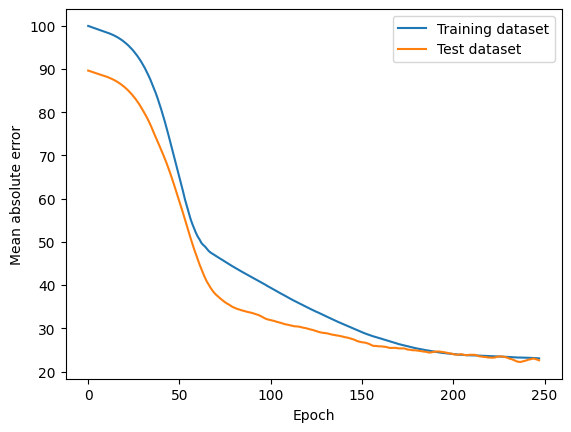

In [184]:
# create training statistics graph
plt.plot(history.history['mae'], label='Training dataset')
plt.plot(history.history['val_mae'], label='Test dataset')
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error')
plt.legend()
plt.show()

In [185]:
mse, mae, R2 = model.evaluate(x_test, y_test, verbose=0)
print("Mean squared error:", mse)
print("Mean absolute error:", mae)
print("Coefficient of determination:", R2)

Mean squared error: 1381.153076171875
Mean absolute error: 22.59572410583496
Coefficient of determination: 0.9551823139190674


In [186]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras_tuner as kt

def cv_stats(model_builder,                       # 1 function that returns empty model
             X, y,
             n_splits=4,
             fit_fn=None,                         # 2 training function (model, X_tr, y_tr, X_val, y_val)
             predict_fn=None,                     # 3 prediction function (model, X)
             **fit_kwargs):
    """
    Returns mean (MAE, MSE, R2) using TimeSeriesSplit.
    model_builder()      → fresh model
    fit_fn(...)          → how to train (by default model.fit)
    predict_fn(model,X)  → how to predict  (by default model.predict)
    """
    if fit_fn is None:
        fit_fn = lambda m, Xtr, ytr, Xv, yv, **kw: m.fit(Xtr, ytr, verbose=0, **kw)
    if predict_fn is None:
        predict_fn = lambda m, X_: m.predict(X_)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    mae, mse, r2 = [], [], []

    for tr, val in tscv.split(X):
        mod = model_builder()          # new model for every fold
        fit_fn(mod, X[tr], y[tr], X[val], y[val], **fit_kwargs)
        y_pred = predict_fn(mod, X[val])
        mae.append(mean_absolute_error(y[val], y_pred))
        mse.append(mean_squared_error(y[val], y_pred))
        r2.append (r2_score         (y[val], y_pred))

    return np.mean(mae), np.mean(mse), np.mean(r2)


# ───────────────────────────────────────────────────────────




mae_nn, mse_nn, r2_nn = cv_stats(createNN, X=x, y=y,
                                 epochs=epoch_count, batch_size=256)
print(f"[NN baseline CV]  MAE={mae_nn:.4f}  MSE={mse_nn:.4f}  R²={r2_nn:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[NN baseline CV]  MAE=32.2450  MSE=4481.8302  R²=0.8774


In [187]:
y_pred = model.predict(x)

print(y_pred.mean())
print(y_pred.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

  print(y_pred.mean())
  print(y_pred.std())

for i in range(lag, len(data)):
  df[[y_name + str(i)+ '_pred']] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

y_mean, y_std = norm_d[y_name]
df['Err'] = df[y_name + str(max_index)] - df[y_name + str(max_index) + '_pred']
df['Err %'] = (df[y_name + str(max_index)] - df[y_name + str(max_index) + '_pred']) / y_mean * 100

tot_err = (df['Err'].apply(lambda x: x**2).mean())**(1/2)
print(tot_err)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
98.702545
177.69887
51.44365659568077


In [188]:
lst = []
for i in range(max(lag, max_index-2), max_index+1):
  lst.append(y_name + str(i))
  lst.append(y_name + str(i) + '_pred')
lst.append('Err')
lst.append('Err %')

df[lst]

,Quantity18,Quantity18_pred,Quantity19,Quantity19_pred,Quantity20,Quantity20_pred,Err,Err %
Code,,,,,,,,
16,53.0,13.538393,8.0,36.418278,9.0,13.515145,-4.515145,-5.711136
22,40.0,43.602253,20.0,28.959143,20.0,17.998758,2.001242,2.531339
39,61.0,37.518147,16.0,39.725674,15.0,18.632271,-3.632271,-4.594402
67,73.0,37.737190,59.0,34.049274,63.0,37.562717,25.437283,32.175215
88,32.0,5.140128,1.0,15.763961,3.0,6.826640,-3.826640,-4.840256
109,35.0,18.537300,9.0,26.390118,15.0,8.437363,6.562637,8.300976
118,63.0,62.923786,30.0,49.158886,8.0,36.105446,-28.105446,-35.550133
119,39.0,7.234224,1.0,26.544069,4.0,6.819682,-2.819682,-3.566571
120,34.0,13.769302,10.0,12.702346,2.0,5.524957,-3.524957,-4.458662


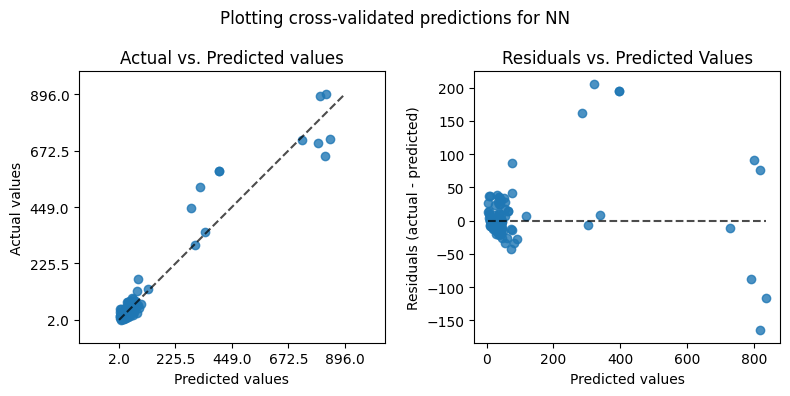

In [189]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions for NN")
plt.tight_layout()
plt.show()

Clusters with NN

In [190]:
print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)


In [191]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [192]:
max_cluster_count = 10

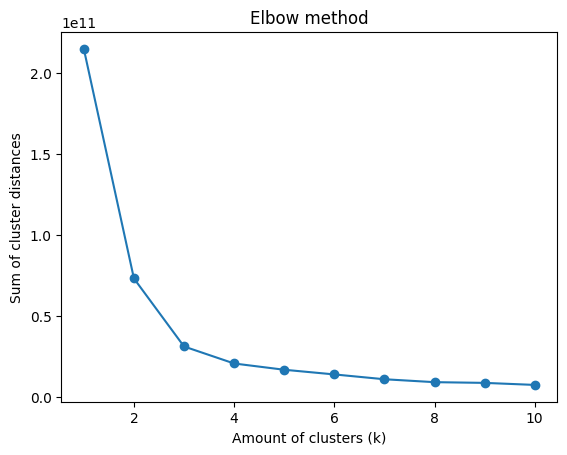

In [193]:
#Elbow method to find optimal amount of clusters for k means
inertia = []
for k in range(1, max_cluster_count+1):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x_cluster)
    inertia.append(kmeans.inertia_)
# Graph
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow method")
plt.xlabel("Amount of clusters (k)")
plt.ylabel("Sum of cluster distances")
plt.show()

In [194]:
cluster_count = 3 # 4 # 12 # 6

In [195]:
kmeans = KMeans(n_clusters=cluster_count, )

# Train model on data
kmeans.fit(x_cluster)

KMeans(n_clusters=3)

In [196]:
# get clusterst for every object
labels = kmeans.labels_

# get coordinates of cluster centres
cluster_centers = kmeans.cluster_centers_

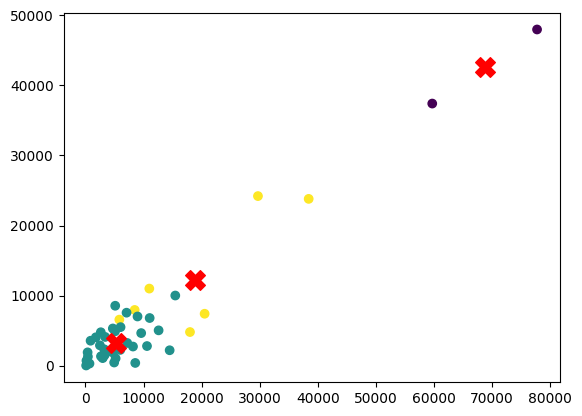

In [197]:
# show results of clusters
import matplotlib.pyplot as plt
plt.scatter(x_cluster[:, -6], x_cluster[:, -2], c=labels, cmap='viridis')
plt.scatter(cluster_centers[:, -6], cluster_centers[:, -2], c='red', marker='X', s=200)
plt.show()

In [198]:
df['Cluster'] = labels
# df[['Dish', 'Cluster']]
df[['Cluster']]
# df

,Cluster
Code,
16,2
22,2
39,2
67,1
88,1
109,1
118,2
119,1
120,1


In [199]:
# for cl in range(cluster_count):
  # print('---- Cluster ' + str(cl))
  # q = df.loc[(df['Cluster'] == cl)]['Dish'].dropna().to_numpy()
  # print(q)

In [200]:
# create dummy variables
tdf = pd.get_dummies(df['Cluster'], dtype=int)

dummy_cols = []
for col in tdf:
  dummy_cols.append('Cluster' + str(col))
  df[dummy_cols[-1]] = tdf[col]

df

,Dish,Quantity0,Wed price0,Sum0,Discount0,Quantity1,Wed price1,Sum1,Discount1,Quantity2,...,Quantity17_pred,Quantity18_pred,Quantity19_pred,Quantity20_pred,Err,Err %,Cluster,Cluster0,Cluster1,Cluster2
Code,,,,,,,,,,,,,,,,,,,,,
16,Sky Lounge Salad,2,720.0,1440,0.0,6.0,720.0,4320,-504.0,5.0,...,21.884163,13.538393,36.418278,13.515145,-4.515145,-5.711136,2,0,0,1
22,Salad with crispy eggplant,6,420.0,2520,-168.0,11.0,420.0,4620,-336.0,12.0,...,57.179588,43.602253,28.959143,17.998758,2.001242,2.531339,2,0,0,1
39,Caesar with chicken fillet and bacon,8,420.0,3360,-252.0,14.0,420.0,5880,-462.0,8.0,...,39.473049,37.518147,39.725674,18.632271,-3.632271,-4.594402,2,0,0,1
67,Kubete,8,120.0,960,-72.0,10.0,120.0,1200,-168.0,5.0,...,58.259174,37.737190,34.049274,37.562717,25.437283,32.175215,1,0,1,0
88,Chicken liver pate with toast,1,390.0,390,-39.0,12.0,390.0,4680,-390.0,5.0,...,5.378050,5.140128,15.763961,6.826640,-3.826640,-4.840256,1,0,1,0
109,Black Sea mussels with tomatoes,4,570.0,2280,-57.0,2.0,570.0,1140,-114.0,6.0,...,9.393599,18.537300,26.390118,8.437363,6.562637,8.300976,1,0,1,0
118,Pork shashlik,3,580.0,1740,-174.0,18.0,580.0,10440,-1044.0,7.0,...,60.126400,62.923786,49.158886,36.105446,-28.105446,-35.550133,2,0,0,1
119,Lamb shashlik,6,850.0,5100,0.0,4.0,850.0,3400,-340.0,2.0,...,20.041803,7.234224,26.544069,6.819682,-2.819682,-3.566571,1,0,1,0
120,Chicken fillet shashlik,2,490.0,980,-49.0,2.0,490.0,980,-98.0,5.0,...,26.290703,13.769302,12.702346,5.524957,-3.524957,-4.458662,1,0,1,0


In [201]:
x = np.empty((0, len(pred_fields)*lag + len(dummy_cols)))
y = np.empty((0, 1))

for i in range(lag, len(data)):
  cols = [] # list(dummy_cols)
  for j in range(i-lag, i):
    cols += [col + str(j) for col in pred_fields]
  # print(cols, y_name + str(i))
  cols += dummy_cols
  x = np.append(x, df[cols].to_numpy(), 0)
  y = np.append(y, df[[y_name + str(i)]].to_numpy(), 0)

print(x.mean(axis=0))
print(x.std(axis=0))

for i in range(len(pred_fields)):
  x_mean, x_std = norm_d[pred_fields[i]]
  if x_std < 1e-8:
        continue
  for j in range(lag):
    x[:,j*len(pred_fields)+i] -= x_mean
    x[:,j*len(pred_fields)+i] /= x_std

print(x.mean(axis=0))
print(x.std(axis=0))

print(x.shape)
print(y.shape)
print(x[:10, :])

[7.41324444e+01 1.12914281e+04 8.08465185e+01 1.23393956e+04
 8.56257778e+01 1.30564978e+04 9.09265185e+01 1.38102563e+04
 9.62702222e+01 1.46716578e+04 1.00424296e+02 1.51546163e+04
 4.44444444e-02 8.00000000e-01 1.55555556e-01]
[1.57819806e+02 1.56481372e+04 1.65851687e+02 1.63080168e+04
 1.71890767e+02 1.67260561e+04 1.77317377e+02 1.70657372e+04
 1.82096736e+02 1.73923296e+04 1.85575617e+02 1.75571618e+04
 2.06080411e-01 4.00000000e-01 3.62433476e-01]
[-0.0301712  -0.03290807  0.01095025  0.03253894  0.04022161  0.07732295
  0.07268687  0.1243962   0.10541527  0.17819191  0.13085758  0.20835333
  0.04444444  0.8         0.15555556]
[0.96659342 0.97724761 1.015786   1.018458   1.05277334 1.04456513
 1.08600951 1.06577868 1.11528148 1.08617482 1.13658846 1.09646882
 0.20608041 0.4        0.36243348]
(675, 15)
(675, 1)
[[-0.47195825 -0.64814326 -0.44745959 -0.46828331 -0.45358425 -0.5132483
  -0.47195825 -0.64814326 -0.45970892 -0.55821328 -0.39846227 -0.10856341
   0.          0.    

In [202]:
print(y.mean())
print(y.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y -= y_mean
  y /= y_std

  print(y.mean())
  print(y.std())

98.6962962962963
184.6072136174963


In [203]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/(len(data) - lag), random_state=42)

In [204]:
print(x_train.shape)
print(x_test.shape)

(630, 15)
(45, 15)


In [205]:
# Create neural network
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])
model.summary() # print model architecture

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_259"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_881 (Dense)               │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_882 (Dense)               │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_883 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081 (8.13 KB)

 Trainable params: 2,081 (8.13 KB)

 Non-trainable params: 0 (0.00 B)

In [206]:
from keras.callbacks import EarlyStopping

# early_stopping_callback = EarlyStopping(monitor='val_mae', patience=patience_count)
early_stopping_callback = EarlyStopping(monitor='val_mae', mode='min', min_delta=0.01, patience=patience_count)

# Start training of NN
history = model.fit(x_train, y_train, batch_size=256, epochs=epoch_count, verbose=2, validation_data=(x_test, y_test), callbacks=[early_stopping_callback])

print("Training stopped on epoch", early_stopping_callback.stopped_epoch)

Epoch 1/500
3/3 - 2s - 591ms/step - loss: 44280.3125 - mae: 99.6172 - r2_score: -2.9075e-01 - val_loss: 38832.0898 - val_mae: 89.3728 - val_r2_score: -2.6008e-01
Epoch 2/500
3/3 - 0s - 126ms/step - loss: 44190.6367 - mae: 99.4605 - r2_score: -2.8813e-01 - val_loss: 38750.2617 - val_mae: 89.2217 - val_r2_score: -2.5743e-01
Epoch 3/500
3/3 - 0s - 44ms/step - loss: 44097.0469 - mae: 99.3090 - r2_score: -2.8540e-01 - val_loss: 38667.8242 - val_mae: 89.0729 - val_r2_score: -2.5475e-01
Epoch 4/500
3/3 - 0s - 37ms/step - loss: 44004.2109 - mae: 99.1585 - r2_score: -2.8270e-01 - val_loss: 38587.0625 - val_mae: 88.9281 - val_r2_score: -2.5213e-01
Epoch 5/500
3/3 - 0s - 34ms/step - loss: 43911.2969 - mae: 99.0113 - r2_score: -2.7999e-01 - val_loss: 38506.8984 - val_mae: 88.7895 - val_r2_score: -2.4953e-01
Epoch 6/500
3/3 - 0s - 48ms/step - loss: 43821.0938 - mae: 98.8724 - r2_score: -2.7736e-01 - val_loss: 38430.6250 - val_mae: 88.6599 - val_r2_score: -2.4705e-01
Epoch 7/500
3/3 - 0s - 42ms/step

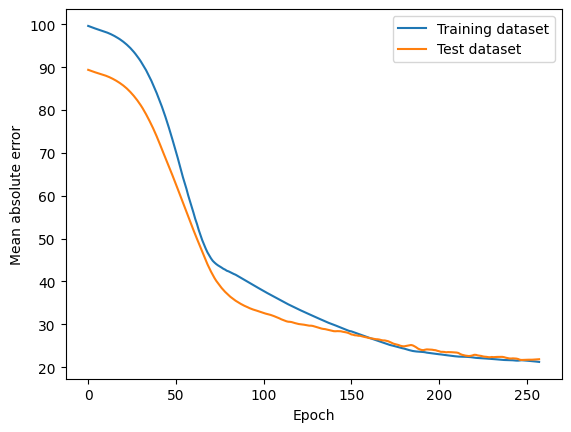

In [207]:
# Create training statistics
plt.plot(history.history['mae'], label='Training dataset')
plt.plot(history.history['val_mae'], label='Test dataset')
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error')
plt.legend()
plt.show()

In [208]:
mse_new, mae_new, R2_new = model.evaluate(x_test, y_test, verbose=0)
print("Mean squared error:", mse, mse_new)
print("Mean absolute error:", mae, mae_new)
print("Coefficient of determination:", R2, R2_new)

Mean squared error: 1381.153076171875 1281.159912109375
Mean absolute error: 22.59572410583496 21.853103637695312
Coefficient of determination: 0.9551823139190674 0.9584270119667053


In [209]:
y_pred = model.predict(x)

print(y_pred.mean())
print(y_pred.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

  print(y_pred.mean())
  print(y_pred.std())

for i in range(lag, len(data)):
  df[[y_name + str(i)+ '_cl_pred']] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]


df['Err'] = df[y_name + str(max_index)] - df[y_name + str(max_index) + '_pred']
df['Err_cl'] = df[y_name + str(max_index)] - df[y_name + str(max_index) + '_cl_pred']

y_mean, y_std = norm_d[y_name]
df['Err %'] = (df[y_name + str(max_index)] - df[y_name + str(max_index) + '_pred']) / y_mean * 100
df['Err_cl %'] = (df[y_name + str(max_index)] - df[y_name + str(max_index) + '_cl_pred']) / y_mean * 100

tot_err = (df['Err_cl'].apply(lambda x: x**2).mean())**(1/2)
print(tot_err)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
97.220634
177.55295
50.35274022401302


In [210]:
lst = []
for i in range(max(lag, max_index-2), max_index+1):
  lst.append(y_name + str(i))
  lst.append(y_name + str(i) + '_cl_pred')
lst.append('Err')
lst.append('Err_cl')
lst.append('Err %')
lst.append('Err_cl %')

df[lst]

,Quantity18,Quantity18_cl_pred,Quantity19,Quantity19_cl_pred,Quantity20,Quantity20_cl_pred,Err,Err_cl,Err %,Err_cl %
Code,,,,,,,,,,
16,53.0,11.517913,8.0,25.581026,9.0,8.954576,-4.515145,0.045424,-5.711136,0.057455
22,40.0,50.061073,20.0,38.185783,20.0,22.843739,2.001242,-2.843739,2.531339,-3.597000
39,61.0,42.139942,16.0,39.637249,15.0,23.149811,-3.632271,-8.149811,-4.594402,-10.308566
67,73.0,52.674927,59.0,48.093071,63.0,50.826199,25.437283,12.173801,32.175215,15.398448
88,32.0,-0.668991,1.0,13.095682,3.0,3.075452,-3.826640,-0.075452,-4.840256,-0.095438
109,35.0,19.089069,9.0,27.683531,15.0,6.216469,6.562637,8.783531,8.300976,11.110149
118,63.0,66.195343,30.0,57.166145,8.0,41.824883,-28.105446,-33.824883,-35.550133,-42.784557
119,39.0,9.757295,1.0,18.201511,4.0,2.850695,-2.819682,1.149305,-3.566571,1.453737
120,34.0,18.357433,10.0,17.844759,2.0,6.834717,-3.524957,-4.834717,-4.458662,-6.115357


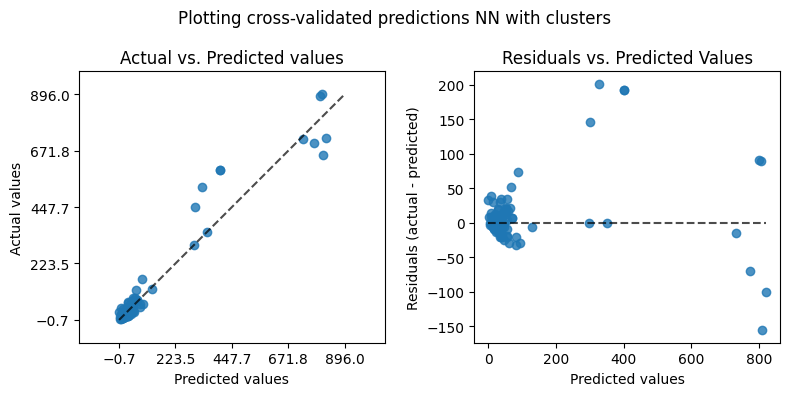

In [211]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions NN with clusters")
plt.tight_layout()
plt.show()

In [212]:
print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)


NARX

In [213]:
x = np.empty((0, lag))
y = np.empty((0, 1))


for i in range(lag, len(data)):
  cols = []
  for j in range(i-lag, i):
    cols += [y_name + str(j)]
  # print(cols, y_name + str(i))
  x = np.append(x, df[cols].to_numpy(), 0)
  y = np.append(y, df[[y_name + str(i)]].to_numpy(), 0)

print(x.mean(axis=0))
print(x.std(axis=0))

x_mean, x_std = norm_d[y_name]
for j in range(lag):
  x[:,j] -= x_mean
  x[:,j] /= x_std

print(x.mean(axis=0))
print(x.std(axis=0))

print(x.shape)
print(y.shape)

[ 74.13244444  80.84651852  85.62577778  90.92651852  96.27022222
 100.4242963 ]
[157.81980592 165.8516868  171.89076735 177.31737654 182.09673649
 185.57561718]
[-0.0301712   0.01095025  0.04022161  0.07268687  0.10541527  0.13085758]
[0.96659342 1.015786   1.05277334 1.08600951 1.11528148 1.13658846]
(675, 6)
(675, 1)


In [214]:
X_narx = x.astype("float32")      # (samples, lag)
y      = y.astype("float32")      # (samples, 1)
assert len(X_narx) == len(y), "X_narx and y must be the same length"

In [215]:
print(y.mean())
print(y.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y -= y_mean
  y /= y_std

  print(y.mean())
  print(y.std())

98.6963
184.60721


In [216]:
src_x_NARX, src_y_NARX = X_narx, y

print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)
print('src_x_NARX, src_y_NARX', src_x_NARX.shape, src_y_NARX.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)
src_x_NARX, src_y_NARX (675, 6) (675, 1)


In [217]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/(len(data) - lag), random_state=42)
x_NARX_train, x_NARX_test, y_NARX_train, y_NARX_test = x_train, x_test, y_train, y_test

In [218]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, LSTM

n_steps = x.shape[1]



# Define and compile the NARX model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(n_steps, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])
model.summary() # print model architecture
narx_bl = model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_260"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_84 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_884 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [219]:
# early_stopping_callback = EarlyStopping(monitor='val_mae', patience=patience_count)
early_stopping_callback = EarlyStopping(monitor='val_mae', mode='min', min_delta=0.01, patience=patience_count)

# Fit the model to the data
history = model.fit(x_train.reshape((x_train.shape[0], x_train.shape[1], 1)), y_train, epochs=epoch_count, verbose=2, validation_data=(x_test, y_test), callbacks=[early_stopping_callback])


print("Training stopped on epoch", early_stopping_callback.stopped_epoch)



Epoch 1/500
20/20 - 3s - 140ms/step - loss: 44153.2305 - mae: 99.2808 - r2_score: -2.8704e-01 - val_loss: 38711.8672 - val_mae: 88.9838 - val_r2_score: -2.5618e-01
Epoch 2/500
20/20 - 0s - 10ms/step - loss: 44002.3789 - mae: 98.8591 - r2_score: -2.8264e-01 - val_loss: 38487.1797 - val_mae: 88.1793 - val_r2_score: -2.4889e-01
Epoch 3/500
20/20 - 0s - 15ms/step - loss: 41471.0977 - mae: 94.3937 - r2_score: -2.0886e-01 - val_loss: 32264.9102 - val_mae: 76.1014 - val_r2_score: -4.6979e-02
Epoch 4/500
20/20 - 0s - 16ms/step - loss: 24966.2285 - mae: 71.6232 - r2_score: 0.2722 - val_loss: 13283.6084 - val_mae: 56.4015 - val_r2_score: 0.5690
Epoch 5/500
20/20 - 0s - 10ms/step - loss: 18093.0957 - mae: 60.5521 - r2_score: 0.4726 - val_loss: 12349.4736 - val_mae: 55.3047 - val_r2_score: 0.5993
Epoch 6/500
20/20 - 0s - 19ms/step - loss: 16245.3887 - mae: 58.4336 - r2_score: 0.5265 - val_loss: 9946.2422 - val_mae: 57.7491 - val_r2_score: 0.6772
Epoch 7/500
20/20 - 0s - 15ms/step - loss: 14640.677

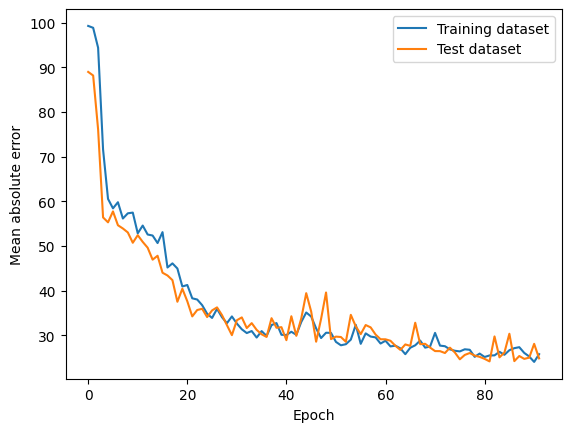

In [220]:
# build training statistics
plt.plot(history.history['mae'], label='Training dataset')
plt.plot(history.history['val_mae'], label='Test dataset')
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error')
plt.legend()
plt.show()

In [221]:
y_pred = model.predict(x.reshape((x.shape[0], x.shape[1], 1)))
print(y_pred.shape)

print(y_pred.mean())
print(y_pred.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

  print(y_pred.mean())
  print(y_pred.std())

for i in range(lag, len(data)):
  df[[y_name + str(i)+ '_NARX']] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

y_mean, y_std = norm_d[y_name]
df['Err NARX'] = df[y_name + str(max_index)] - df[y_name + str(max_index) + '_NARX']
df['Err NARX %'] = df['Err NARX'] / y_mean * 100

tot_err = (df['Err NARX'].apply(lambda x: x**2).mean())**(1/2)
print(tot_err)

lst = []
for i in range(max(lag, max_index-2), max_index+1):
  lst.append(y_name + str(i))
  lst.append(y_name + str(i) + '_NARX')
lst.append('Err NARX %')
df[lst]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(675, 1)
93.99632
168.72429
62.037110517991735


,Quantity18,Quantity18_NARX,Quantity19,Quantity19_NARX,Quantity20,Quantity20_NARX,Err NARX %
Code,,,,,,,
16,53.0,34.351601,8.0,32.474495,9.0,32.063480,-29.172631
22,40.0,58.177650,20.0,49.170944,20.0,44.019447,-30.381818
39,61.0,49.874168,16.0,48.373512,15.0,47.678215,-41.334156
67,73.0,66.257362,59.0,54.733894,63.0,54.911552,10.230949
88,32.0,27.201395,1.0,25.853872,3.0,25.073736,-27.920719
109,35.0,28.401876,9.0,29.608812,15.0,29.838923,-18.769518
118,63.0,59.779091,30.0,53.721703,8.0,53.707283,-57.814417
119,39.0,29.543276,1.0,26.866068,4.0,25.920855,-27.727341
120,34.0,40.332832,10.0,36.212227,2.0,32.961296,-39.162452


In [222]:
mse_new2, mae_new2, R2_new2 = model.evaluate(x_test, y_test, verbose=0)
print("Mean squared error:", mse, mse_new2)
print("Mean absolute error:", mae, mae_new2)
print("Coefficient of determination:", R2, R2_new2)

Mean squared error: 1381.153076171875 1966.0535888671875
Mean absolute error: 22.59572410583496 24.842649459838867
Coefficient of determination: 0.9551823139190674 0.9362025856971741


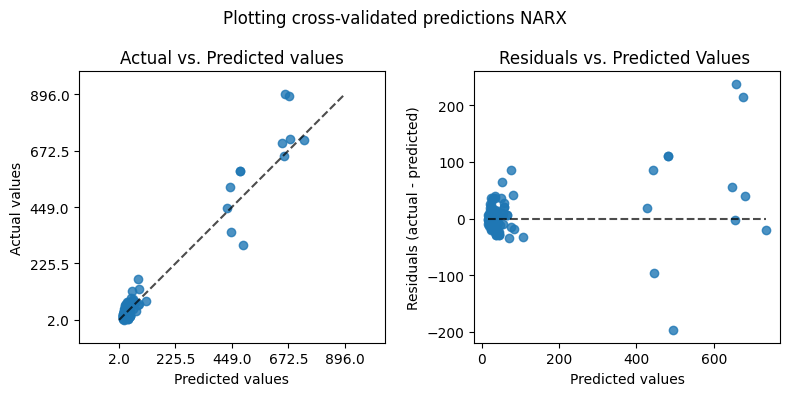

In [223]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values ")
fig.suptitle("Plotting cross-validated predictions NARX")
plt.tight_layout()
plt.show()

XGB

In [224]:
src_x_XGB, src_y_XGB = src_x_NN, src_y_NN

print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)
print('src_x_NARX, src_y_NARX', src_x_NARX.shape, src_y_NARX.shape)
print('src_x_XGB, src_y_XGB', src_x_XGB.shape, src_y_XGB.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)
src_x_NARX, src_y_NARX (675, 6) (675, 1)
src_x_XGB, src_y_XGB (675, 12) (675, 1)


In [225]:
x = np.empty((0, len(pred_fields)*lag))
y = np.empty((0, 1))

for i in range(lag, len(data)):
  cols = []
  for j in range(i-lag, i):
    cols += [col + str(j) for col in pred_fields]
  # print(cols, y_name + str(i))
  x = np.append(x, df[cols].to_numpy(), 0)
  y = np.append(y, df[[y_name + str(i)]].to_numpy(), 0)

print(x.mean(axis=0))
print(x.std(axis=0))

for i in range(len(pred_fields)):
  x_mean, x_std = norm_d[pred_fields[i]]
  if x_std < 1e-8:
        continue
  for j in range(lag):
    x[:,j*len(pred_fields)+i] -= x_mean
    x[:,j*len(pred_fields)+i] /= x_std

print(x.mean(axis=0))
print(x.std(axis=0))

print(x.shape)
print(y.shape)

[   74.13244444 11291.42814815    80.84651852 12339.39555556
    85.62577778 13056.49777778    90.92651852 13810.2562963
    96.27022222 14671.65777778   100.4242963  15154.6162963 ]
[  157.81980592 15648.1371751    165.8516868  16308.01683823
   171.89076735 16726.05613051   177.31737654 17065.73720701
   182.09673649 17392.32963374   185.57561718 17557.16184841]
[-0.0301712  -0.03290807  0.01095025  0.03253894  0.04022161  0.07732295
  0.07268687  0.1243962   0.10541527  0.17819191  0.13085758  0.20835333]
[0.96659342 0.97724761 1.015786   1.018458   1.05277334 1.04456513
 1.08600951 1.06577868 1.11528148 1.08617482 1.13658846 1.09646882]
(675, 12)
(675, 1)


In [226]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/(len(data) - lag), random_state=42)

In [227]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Specify which dataset and which metric should be used for early stopping.
early_stop = xgb.callback.EarlyStopping(
    rounds=patience_count,
    metric_name='mae',
    # data_name="Valid",
    save_best=True)

verbosity_level=1

xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    tree_method="hist",
    eval_metric='mae',
    callbacks=[early_stop],
    verbosity=verbosity_level,
)

xgb.set_config(verbosity=verbosity_level)



In [228]:
history = xgb_regressor.fit(x_train, y_train, eval_set=[(x_test, y_test)], verbose=True)


[0]	validation_0-mae:93.39961
[1]	validation_0-mae:84.89480
[2]	validation_0-mae:77.60638
[3]	validation_0-mae:70.41568
[4]	validation_0-mae:64.48795
[5]	validation_0-mae:59.02648
[6]	validation_0-mae:53.70864
[7]	validation_0-mae:49.47300
[8]	validation_0-mae:45.73377
[9]	validation_0-mae:42.31772
[10]	validation_0-mae:39.30021
[11]	validation_0-mae:36.74945
[12]	validation_0-mae:34.72364
[13]	validation_0-mae:32.93231
[14]	validation_0-mae:31.44114
[15]	validation_0-mae:29.75754
[16]	validation_0-mae:28.56215
[17]	validation_0-mae:27.26319
[18]	validation_0-mae:26.26018
[19]	validation_0-mae:25.28297
[20]	validation_0-mae:24.55727
[21]	validation_0-mae:24.05198
[22]	validation_0-mae:23.30790
[23]	validation_0-mae:22.83024
[24]	validation_0-mae:22.24311
[25]	validation_0-mae:21.93834
[26]	validation_0-mae:21.70600
[27]	validation_0-mae:21.37736
[28]	validation_0-mae:21.11118
[29]	validation_0-mae:20.94304
[30]	validation_0-mae:20.84009
[31]	validation_0-mae:20.69450
[32]	validation_0-

In [229]:
y_pred = xgb_regressor.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

mae = mean_absolute_error(y_test,y_pred)
print("MAE: %.2f" % mae)

Mean Squared Error: 805.6086
R² Score: 0.9739
MAE: 19.26


In [230]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

dtrain = xgb.DMatrix(x_test, label=y_train)
dtest   = xgb.DMatrix(x_test,   label=y_test)
# Convert to XGBoost DMatrix
dtrain = xgb.DMatrix(x_train, label=y_train)
dval   = xgb.DMatrix(x_test,   label=y_test)

history_mae = []
history_val_mae = []

# bst = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=1,
#     )
# train_preds = bst.predict(dtrain)
# test_preds   = bst.predict(dval)

params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.1,
    "max_depth": 5,
    "seed": 42
}
num_epochs = 150
bst = None
for epoch in range(num_epochs):
    start_time = time.time()

    # Train exactly 1 boosting round, continuing from the previous model
    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=1,
        xgb_model=bst  # Continue from previous iteration
    )

    # Compute predictions on training and validation sets
    train_preds = bst.predict(dtrain)
    test_preds   = bst.predict(dval)

    # Calculate metrics
    train_mae  = mean_absolute_error(y_train, train_preds)
    history_mae.append(train_mae)
    train_mse  = mean_squared_error(y_train, train_preds)
    train_rmse = train_mse ** 0.5
    train_r2   = r2_score(y_train, train_preds)

    val_mae  = mean_absolute_error(y_test, test_preds)
    history_val_mae.append(val_mae)
    val_mse  = mean_squared_error(y_test, test_preds)
    val_rmse = val_mse ** 0.5
    val_r2   = r2_score(y_test, test_preds)

    # Elapsed time for this epoch
    elapsed_time = time.time() - start_time

    # “Keras‐style” printout
    # E.g., "Epoch 1/10  - 0.02s - loss: ... - mae: ... - val_loss: ... - val_mae: ... - val_r2: ..."
    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"{elapsed_time:.2f}s - "
        f"train_rmse: {train_rmse:.4f} - train_mae: {train_mae:.4f} - train_r2: {train_r2:.4f} - "
        f"val_rmse: {val_rmse:.4f} - val_mae: {val_mae:.4f} - val_r2: {val_r2:.4f}"
    )

Epoch 1/150 - 0.01s - train_rmse: 167.9476 - train_mae: 99.6794 - train_r2: 0.1778 - val_rmse: 159.7412 - val_mae: 93.3996 - val_r2: 0.1720
Epoch 2/150 - 0.03s - train_rmse: 152.4285 - train_mae: 90.0982 - train_r2: 0.3227 - val_rmse: 145.7832 - val_mae: 84.8948 - val_r2: 0.3104
Epoch 3/150 - 0.04s - train_rmse: 138.4627 - train_mae: 81.5689 - train_r2: 0.4411 - val_rmse: 133.9816 - val_mae: 77.6064 - val_r2: 0.4175
Epoch 4/150 - 0.03s - train_rmse: 125.8697 - train_mae: 73.8763 - train_r2: 0.5382 - val_rmse: 122.2944 - val_mae: 70.4157 - val_r2: 0.5147
Epoch 5/150 - 0.23s - train_rmse: 114.5480 - train_mae: 67.0142 - train_r2: 0.6175 - val_rmse: 112.5801 - val_mae: 64.4879 - val_r2: 0.5887
Epoch 6/150 - 0.02s - train_rmse: 104.2007 - train_mae: 60.7494 - train_r2: 0.6835 - val_rmse: 103.7820 - val_mae: 59.0265 - val_r2: 0.6505
Epoch 7/150 - 0.02s - train_rmse: 94.9726 - train_mae: 55.1692 - train_r2: 0.7371 - val_rmse: 95.1630 - val_mae: 53.7086 - val_r2: 0.7061
Epoch 8/150 - 0.02s - 

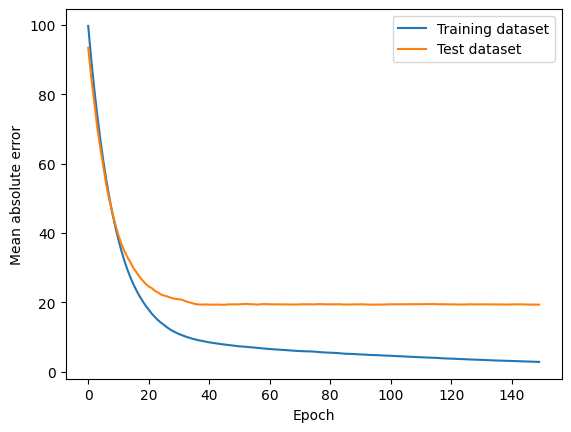

In [231]:
# create a training statistics
plt.plot(history_mae, label='Training dataset')
plt.plot(history_val_mae, label='Test dataset')
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error')
plt.legend()
plt.show()

In [232]:
y_pred = np.array(xgb_regressor.predict(x))
y_pred = y_pred.reshape((len(y_pred), 1))
print(y_pred.shape)

print(y_pred.mean())
print(y_pred.std())

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

  print(y_pred.mean())
  print(y_pred.std())

for i in range(lag, len(data)):
  df[[y_name + str(i)+ '_XGB']] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

y_mean, y_std = norm_d[y_name]
df['Err XGB'] = (df[y_name + str(max_index)] - df[y_name + str(max_index) + '_XGB'])
df['Err XGB %'] = df['Err XGB'] / y_mean * 100

tot_err = (df['Err XGB'].apply(lambda x: x**2).mean())**(1/2)
print(tot_err)

lst = []
for i in range(max(lag, max_index-2), max_index+1):
  lst.append(y_name + str(i))
  lst.append(y_name + str(i) + '_XGB')
lst.append('Err XGB')
lst.append('Err XGB %')
df[lst]

(675, 1)
98.45405
181.14267
16.62484467046126


,Quantity18,Quantity18_XGB,Quantity19,Quantity19_XGB,Quantity20,Quantity20_XGB,Err XGB,Err XGB %
Code,,,,,,,,
16,53.0,41.929420,8.0,20.534847,9.0,14.135457,-5.135457,-6.495758
22,40.0,50.308037,20.0,30.832720,20.0,20.557079,-0.557079,-0.704641
39,61.0,56.074406,16.0,46.642986,15.0,15.903005,-0.903005,-1.142196
67,73.0,75.848419,59.0,63.366753,63.0,60.369892,2.630108,3.326782
88,32.0,16.825720,1.0,18.327732,3.0,13.396847,-10.396847,-13.150807
109,35.0,30.392996,9.0,27.149775,15.0,16.178574,-1.178574,-1.490759
118,63.0,66.557777,30.0,43.931408,8.0,20.785221,-12.785221,-16.171823
119,39.0,7.542141,1.0,16.188950,4.0,10.112037,-6.112037,-7.731018
120,34.0,28.015572,10.0,25.327391,2.0,18.565794,-16.565794,-20.953810


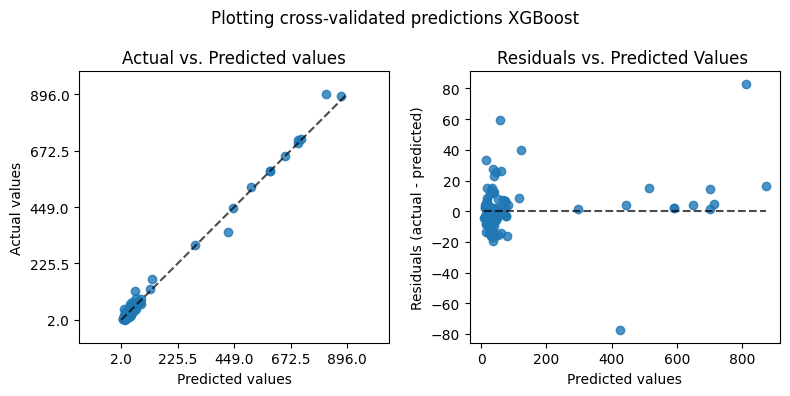

In [233]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values ")
fig.suptitle("Plotting cross-validated predictions XGBoost")
plt.tight_layout()
plt.show()

Hybrid model (NARX + XGBoost)

In [234]:
src_x_Hybrid, src_y_Hybrid = src_x_NARX, src_y_NARX
x_train, x_test, y_train, y_test = x_NARX_train, x_NARX_test, y_NARX_train, y_NARX_test

print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)
print('src_x_NARX, src_y_NARX', src_x_NARX.shape, src_y_NARX.shape)
print('src_x_XGB, src_y_XGB', src_x_XGB.shape, src_y_XGB.shape)
print('src_x_Hybrid, src_y_Hybrid', src_x_Hybrid.shape, src_y_Hybrid.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)
src_x_NARX, src_y_NARX (675, 6) (675, 1)
src_x_XGB, src_y_XGB (675, 12) (675, 1)
src_x_Hybrid, src_y_Hybrid (675, 6) (675, 1)


In [235]:
print(x_train.shape)
print(y_train.shape)

(630, 6)
(630, 1)


In [236]:
BL_LSTM_UNITS     = 64
BL_ACTIVATION     = 'relu'
BL_XGB_DEPTH      = 5
BL_XGB_N_ESTIM    = 200

# resid_bl = y - narx_bl.predict(
    # X_narx.reshape((-1, lag, 1)), verbose=0)\

resid_bl = y_train - narx_bl.predict(
    x_train.reshape((-1, lag, 1)), verbose=0)\
# resid_bl = y_train - narx_bl.predict(x_train, verbose=0)

xgb_bl = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=BL_XGB_DEPTH,
    n_estimators=BL_XGB_N_ESTIM,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='mae',
    verbosity=0)
# xgb_bl.fit(X_narx, resid_bl)
xgb_bl.fit(x_train, resid_bl)

# xgb_bl = xgb_regressor

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

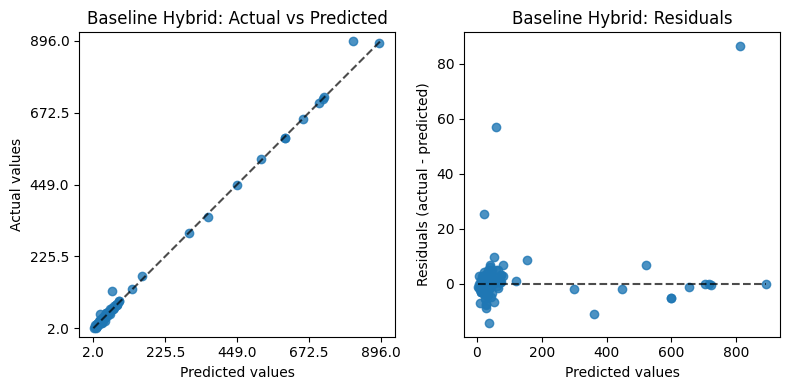

In [237]:
# ── Baseline hybrid ──────────────────────────────────────────────
base_pred  = narx_bl.predict(X_narx.reshape((-1, lag, 1)), verbose=0).flatten()
resid_pred = xgb_bl.predict(X_narx)
y_pred_bas = base_pred + resid_pred        # 1‑D, shape = (n_samples,)


y_true = y.squeeze()                       # (n_samples,)

#  test
assert y_true.shape[0] == y_pred_bas.shape[0]

# ── graphs ──────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

PredictionErrorDisplay.from_predictions(
    y_true, y_pred_bas,
    kind="actual_vs_predicted",
    subsample=100, ax=ax[0], random_state=0)
ax[0].set_title("Baseline Hybrid: Actual vs Predicted")

PredictionErrorDisplay.from_predictions(
    y_true, y_pred_bas,
    kind="residual_vs_predicted",
    subsample=100, ax=ax[1], random_state=0)
ax[1].set_title("Baseline Hybrid: Residuals")

plt.tight_layout(); plt.show()
# otherwise ValueError: x and y must be the same size

In [238]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import xgboost as xgb
"""Hybrid model"""
# ============================================================================
#  A.  BASELINE
# ============================================================================

# --- NARX (LSTM)
narx_bl = Sequential([
    LSTM(BL_LSTM_UNITS, activation=BL_ACTIVATION, input_shape=(lag, 1)),
    Dense(1)
])
narx_bl.compile(optimizer='adam', loss='mse', metrics=['mae'])

narx_bl.fit(
    x_train.reshape((-1, lag, 1)), y_train,
    epochs=epoch_count, batch_size=batch_size,
    verbose=0
)


# --- XGB
# resid_bl = y - narx_bl.predict(
    # X_narx.reshape((-1, lag, 1)), verbose=0)
resid_bl = y_train - narx_bl.predict(
    x_train.reshape((-1, lag, 1)), verbose=0)

xgb_bl = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=BL_XGB_DEPTH,
    n_estimators=BL_XGB_N_ESTIM,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='mae',
    # callbacks=[early_stop],
    verbosity=0)
# xgb_bl.fit(X_narx, resid_bl)
xgb_bl.fit(x_train, resid_bl)




/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

[BASELINE]  MSE: 831.5559  MAE: 19.3451  R²: 0.9730


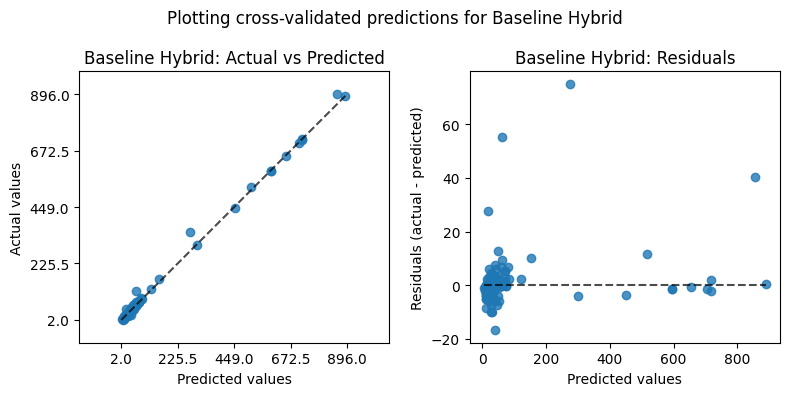

In [239]:
# --- Predictions Baseline
# base_pred   = narx_bl.predict(
#     X_narx.reshape((-1, lag, 1)), verbose=0).flatten()
# resid_pred  = xgb_bl.predict(X_narx)
base_pred   = narx_bl.predict(
    x_test.reshape((-1, lag, 1)), verbose=0).flatten()
resid_pred  = xgb_bl.predict(x_test)
y_pred_bas  = base_pred + resid_pred

# mse_bas = mean_squared_error(y, y_pred_bas)
# mae_bas = mean_absolute_error(y, y_pred_bas)
# r2_bas  = r2_score(y, y_pred_bas)
mse_bas = mean_squared_error(y_test, y_pred_bas)
mae_bas = mean_absolute_error(y_test, y_pred_bas)
r2_bas  = r2_score(y_test, y_pred_bas)
print(f"[BASELINE]  MSE: {mse_bas:.4f}  MAE: {mae_bas:.4f}  R²: {r2_bas:.4f}")

y_true = y.squeeze()
base_pred   = narx_bl.predict(
    src_x_Hybrid.reshape((-1, lag, 1)), verbose=0).flatten()
resid_pred  = xgb_bl.predict(src_x_Hybrid)
y_pred_bas  = base_pred + resid_pred

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_true, y_pred_bas, kind="actual_vs_predicted",
    subsample=100, ax=ax[0], random_state=0)
ax[0].set_title("Baseline Hybrid: Actual vs Predicted")

PredictionErrorDisplay.from_predictions(
    y_true, y_pred_bas, kind="residual_vs_predicted",
    subsample=100, ax=ax[1], random_state=0)
ax[1].set_title("Baseline Hybrid: Residuals")
fig.suptitle("Plotting cross-validated predictions for Baseline Hybrid")
plt.tight_layout(); plt.show()



In [240]:
# ============================================================================
#  B.  Hyperparameters optimization  (TimeSeriesSplit)
# ============================================================================

def build_hybrid_hp(hp):
    hp.Int   ("lstm_units",     32, 128, 16)
    hp.Choice("activation",     values=choice_activation)
    hp.Int   ("xgb_depth",       3,   7,  1)
    hp.Int   ("xgb_estimators", 100, 300, 50)
    return True

class HybridTSTuner(kt.RandomSearch):
    def run_trial(self, trial, X, y,
                  n_splits: int = 4,
                  epochs: int   = choice_epochs,
                  batch_size: int = choice_batch_size):
        hp   = trial.hyperparameters
        tscv = TimeSeriesSplit(n_splits=n_splits)
        fold_mae = []

        for tr, val in tscv.split(X):
            # --- NARX
            narx = Sequential([
                LSTM(hp["lstm_units"],
                     activation=hp["activation"],
                     input_shape=(lag, 1)),
                Dense(1)
            ])
            narx.compile(optimizer='adam', loss='mse', metrics=['mae'])
            narx.fit(
                X[tr].reshape((-1, lag, 1)), y[tr],
                validation_data=(X[val].reshape((-1, lag, 1)), y[val]),
                epochs=epochs, batch_size=batch_size, verbose=0)

            resid_tr = y[tr] - narx.predict(
                X[tr].reshape((-1, lag, 1)), verbose=0)

            # --- XGB
            xgb_model = xgb.XGBRegressor(
                objective='reg:squarederror',
                max_depth=hp["xgb_depth"],
                n_estimators=hp["xgb_estimators"],
                learning_rate=0.1,
                tree_method='hist',
                eval_metric='mae',
                verbosity=0)
            xgb_model.fit(X[tr], resid_tr)

            base_val  = narx.predict(
                X[val].reshape((-1, lag, 1)), verbose=0).flatten()
            resid_val = xgb_model.predict(X[val])
            fold_mae.append(mean_absolute_error(y[val], base_val + resid_val))

        self.oracle.update_trial(
            trial.trial_id, metrics={"val_mae": float(np.mean(fold_mae))})

hybrid_tuner = HybridTSTuner(
    hypermodel=build_hybrid_hp,
    objective="val_mae",
    max_trials=max_trials_count,
    directory="models_hybrid_ts")

# hybrid_tuner.search(
#     X_narx, y,
#     n_splits=4,
#     epochs=choice_epochs,
#     batch_size=choice_batch_size)

hybrid_tuner.search(
    x_train, y_train,
    n_splits=4,
    epochs=choice_epochs,
    batch_size=choice_batch_size)

best_hp = hybrid_tuner.get_best_hyperparameters(1)[0]
print("Best HP Hybrid:", best_hp.values)

# ============================================================================
#  C.  Metrics + graphs            <<–– after optimization
# ============================================================================

narx_best = Sequential([
    LSTM(best_hp["lstm_units"],
         activation=best_hp["activation"],
         input_shape=(lag, 1)),
    Dense(1)
])
narx_best.compile(optimizer='adam', loss='mse', metrics=['mae'])
# narx_best.fit(
#     X_narx.reshape((-1, lag, 1)), y,
#     epochs=choice_epochs, batch_size=choice_batch_size,
#     callbacks=[EarlyStopping(monitor='mae',
#                              patience=patience_count,
#                              restore_best_weights=True,
#                              verbose=0)],
#     verbose=0)
narx_best.fit(
    x_train.reshape((-1, lag, 1)), y_train,
    epochs=choice_epochs, batch_size=choice_batch_size,
    callbacks=[EarlyStopping(monitor='mae',
                             patience=patience_count,
                             restore_best_weights=True,
                             verbose=0)],
    verbose=0)

# resid_best = y - narx_best.predict(
#     X_narx.reshape((-1, lag, 1)), verbose=0)
resid_best = y_train - narx_best.predict(
    x_train.reshape((-1, lag, 1)), verbose=0)

xgb_best = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=best_hp["xgb_depth"],
    n_estimators=best_hp["xgb_estimators"],
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='mae',
    verbosity=0)
# xgb_best.fit(X_narx, resid_best)
xgb_best.fit(x_train, resid_best)



Reloading Tuner from models_hybrid_ts/untitled_project/tuner0.json
Best HP Hybrid: {'lstm_units': 80, 'activation': 'relu', 'xgb_depth': 3, 'xgb_estimators': 100}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

[BEST HP]   MSE: 779.9506  MAE: 19.0685  R²: 0.9747


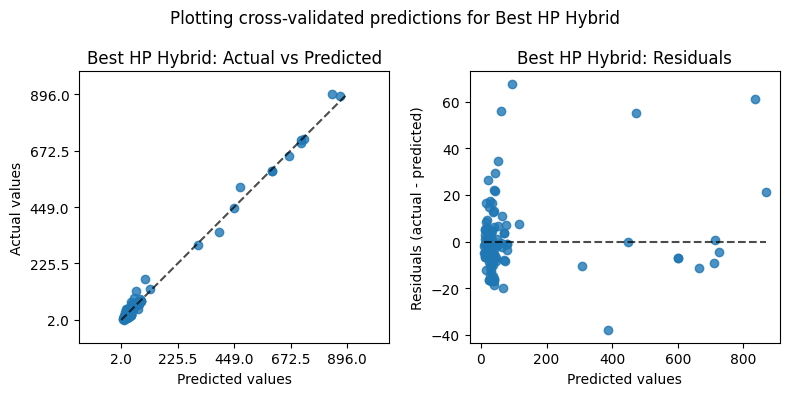

In [241]:

base_best   = narx_best.predict(
    x_test.reshape((-1, lag, 1)), verbose=0).flatten()
resid_best  = xgb_best.predict(x_test)
y_pred_best = base_best + resid_best


mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best  = r2_score(y_test, y_pred_best)
print(f"[BEST HP]   MSE: {mse_best:.4f}  MAE: {mae_best:.4f}  R²: {r2_best:.4f}")


base_best   = narx_best.predict(
    X_narx.reshape((-1, lag, 1)), verbose=0).flatten()
resid_best  = xgb_best.predict(X_narx)
y_pred_best = base_best + resid_best

y_true = y.squeeze()


fig, ax = plt.subplots(1, 2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_true, y_pred_best, kind="actual_vs_predicted",
    subsample=100, ax=ax[0], random_state=0)
ax[0].set_title("Best HP Hybrid: Actual vs Predicted")

PredictionErrorDisplay.from_predictions(
    y_true, y_pred_best, kind="residual_vs_predicted",
    subsample=100, ax=ax[1], random_state=0)
ax[1].set_title("Best HP Hybrid: Residuals")
fig.suptitle("Plotting cross-validated predictions for Best HP Hybrid")
plt.tight_layout(); plt.show()
# ============================================================================


In [242]:
# Predictions for best models
preddf = df[show_fields].copy()

In [243]:
y_pred = y_pred_best

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

for i in [len(data)-1]:
  preddf['Hybrid'] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

hyperparameter optimization

In [244]:
print('src_x_NN, src_y_NN', src_x_NN.shape, src_y_NN.shape)
print('src_x_NARX, src_y_NARX', src_x_NARX.shape, src_y_NARX.shape)
print('src_x_XGB, src_y_XGB', src_x_XGB.shape, src_y_XGB.shape)
print('src_x_Hybrid, src_y_Hybrid', src_x_Hybrid.shape, src_y_Hybrid.shape)

src_x_NN, src_y_NN (675, 12) (675, 1)
src_x_NARX, src_y_NARX (675, 6) (675, 1)
src_x_XGB, src_y_XGB (675, 12) (675, 1)
src_x_Hybrid, src_y_Hybrid (675, 6) (675, 1)


In [245]:
print('x, y', x.shape, y.shape)

x, y (675, 12) (675, 1)


In [246]:
models_res_array = []
# (aim, model_type, params, stats, model, tuner)

In [247]:
model_type_NN = 'NN'
model_type_CNN = 'ClusterNN'
model_type_NARX = 'NARX'
model_type_XGB = 'XGB'
model_type_Hybrid = 'Hybrid'

def add_res_model(model_type, model, X_val, y_val):
    """
    Saves model and its MAE on given validation dataset.
      model_type  –  ('ClusterNN', 'NN', …)
      model       – created Keras-model
      X_val, y_val – data of the same dimension, as the data which model trained on
    """
    mae = model.evaluate(X_val, y_val, verbose=0)[1]   # metrics=['mae']
    models_res_array.append((mae, model_type, model))


def add_simple_res_model(model_type, model, params, x_tst=x_test, y_tst=y_test):
  # ev = model.evaluate(x_tuner_test, y_tuner_test)
  y_pred = model.predict(x_tst)
  aim = mean_absolute_error(y_tst,y_pred)
  models_res_array.append((aim, model_type, model, params))

def add_aim_res_model(model_type, aim, params):
  models_res_array.append((aim, model_type, params))

def myFunc(e):
  return e[0]

def get_best_models(count):
  models_res_array.sort(reverse=aim_maximization, key=myFunc)
  return models_res_array[:count]

In [248]:
aim = mae_best

add_aim_res_model(model_type_Hybrid, aim, [(aim, model_type_NARX, narx_best), (aim, model_type_XGB, xgb_best)])

In [249]:
early_stopping_callback = EarlyStopping(monitor='val_mae', mode='min', min_delta=0.01, patience=patience_count)

In [250]:
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split

x_tuner_train, x_tuner_test, y_tuner_train, y_tuner_test = train_test_split(
    x, y, test_size=0.2, random_state=42                # 20 % on validation
)
# ─────────────────────────────────────────────

In [251]:
x_tuner_train, x_tuner_test, y_tuner_train, y_tuner_test = train_test_split(src_x_NN, src_y_NN, test_size=1/(len(data) - lag), random_state=42)

print(x_tuner_train.shape, x_tuner_test.shape, y_tuner_train.shape, y_tuner_test.shape)

(630, 12) (45, 12) (630, 1) (45, 1)


In [252]:
x_NN_train, x_NN_test, y_NN_train, y_NN_test = x_tuner_train, x_tuner_test, y_tuner_train, y_tuner_test

In [253]:
tunerNN = TSTuner(
    hypermodel=build_NN,
    objective="val_mae",
    max_trials=max_trials_count,
    directory="models4_ts")

tunerNN.search(x_tuner_train, y_tuner_train, n_splits=4, callbacks=[early_stopping_callback])
# show_best_metrics(tunerNN, x_test, y_test, tag="NN Best")

show_best_metrics(tunerNN, x_tuner_test, y_tuner_test, tag="NN Best")

Reloading Tuner from models4_ts/untitled_project/tuner0.json
[NN Best]  MSE: 3046.2344  MAE: 40.4855  R²: 0.9012


In [254]:
tunerNN.search_space_summary()

Search space summary
Default search space size: 8
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh', 'elu', 'selu'], 'ordered': False}
dense_count (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
units_hidden2 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
units_hidden3 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
units_hidden4 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
units_hidden5 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'r

In [255]:
available = sum(t.status == "COMPLETED"
                  for t in tunerNN.oracle.trials.values())
k = min(best_num_count, available)
models = tunerNN.get_best_models(num_models=k)#, include_weights=False)

for model in models:
    model.summary()
    # rate on the data of this cluster
    add_res_model(model_type_NN, model, x_NN_test, y_NN_test)
    print()

Model: "sequential_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_89 (Dense)                │ (None, 224)            │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 208)            │        46,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 1)              │           209 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,844 (390.02 KB)

 Trainable params: 49,921 (195.00 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_206 (Dense)               │ (None, 144)            │         1,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_207 (Dense)               │ (None, 208)            │        30,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_208 (Dense)               │ (None, 48)             │        10,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_209 (Dense)               │ (None, 224)            │        10,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_210 (Dense)               │ (None, 128)            │        28,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_211 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,940 (640.39 KB)

 Trainable params: 81,969 (320.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,971 (320.20 KB)

In [256]:
model = tunerNN.get_best_models(num_models=1)[0]
y_pred = model.predict(src_x_NN)

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

for i in [len(data)-1]:
  preddf['NN'] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Clusters with NN

In [257]:
models_Cl_NN = {}
cluster_data = {}

for cl_count in range(2, 5):
  kmeans = KMeans(n_clusters=cluster_count, )
  kmeans.fit(x_cluster)

  labels = kmeans.labels_
  df['Cluster'] = labels

  # create dummy variables
  tdf = pd.get_dummies(df['Cluster'], dtype=int)

  dummy_cols = []
  for col in tdf:
    dummy_cols.append('Cluster' + str(col))
    df[dummy_cols[-1]] = tdf[col]

  x_cl = np.empty((0, len(pred_fields)*lag + len(dummy_cols)))
  y_cl = np.empty((0, 1))

  for i in range(lag, len(data)):
    cols = [] # list(dummy_cols)
    for j in range(i-lag, i):
      cols += [col + str(j) for col in pred_fields]
    # print(cols, y_name + str(i))
    cols += dummy_cols
    x_cl = np.append(x_cl, df[cols].to_numpy(), 0)
    y_cl = np.append(y_cl, df[[y_name + str(i)]].to_numpy(), 0)

  for i in range(len(pred_fields)):
    x_mean, x_std = norm_d[pred_fields[i]]

    if x_std < 1e-8:
        continue

    for j in range(lag):
        col_idx = j*len(pred_fields) + i
        x_cl[:, col_idx] -= x_mean
        x_cl[:, col_idx] /= x_std

  x_train, x_test, y_train, y_test = train_test_split(x_cl, y_cl, test_size=1/(len(data) - lag), random_state=42)

  input_dim = x_train.shape[1]         #  ← 15, 18, …  different in every iteration
  tunerCNN  = TSTuner(
      hypermodel=make_build_NN(input_dim),
      objective="val_mae",
      max_trials=max_trials_count,
      overwrite  = True,
      directory  = f"models_cl_{cl_count}")


  X_cl = x_cl


  tunerCNN.search(x_train, y_train,
                  validation_data=(x_test, y_test),
                  callbacks=[early_stopping_callback]
    )
  show_best_metrics(tunerCNN, x_test, y_test, tag="ClusterNN Best")
  cluster_data[cl_count] = (x_test, y_test)

  print('--- Cluster count:', cl_count)

  available = sum(t.status == "COMPLETED"
                  for t in tunerCNN.oracle.trials.values())
  k = min(best_num_count, available)
  models = tunerCNN.get_best_models(num_models=k)#, include_weights=False)
  models_Cl_NN[cl_count] = models

  for model in models:
      model.summary()
      # rate on the data of this cluster
      add_res_model(model_type_CNN, model, x_test, y_test)
      print()

  model = models[0]
  y_pred = model.predict(x_cl)

  if y_normalize:
    y_mean, y_std = norm_d[y_name]
    y_pred *= y_std
    y_pred += y_mean

  for i in [len(data)-1]:
    preddf['CNN_' + str(cl_count)] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

Trial 10 Complete [00h 00m 37s]
val_mae: 30.047661781311035

Best val_mae So Far: 30.047661781311035
Total elapsed time: 00h 03m 47s
[ClusterNN Best]  MSE: 1067.3566  MAE: 20.3609  R²: 0.9654
--- Cluster count: 4


Model: "sequential_385"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1426 (Dense)              │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1427 (Dense)              │ (None, 208)            │        53,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1428 (Dense)              │ (None, 192)            │        40,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1429 (Dense)              │ (None, 176)            │        33,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1430 (Dense)              │ (None, 96)             │        16,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1431 (Dense)              │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,213 (1.70 MB)

 Trainable params: 148,737 (581.00 KB)

...

 Total params: 24,147 (94.33 KB)

 Trainable params: 24,145 (94.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [258]:
for cl_count, models in models_Cl_NN.items():
  print('--- Cluster count:', cl_count)
  x_tuner_test, y_tuner_test = cluster_data[cl_count]

  for model in models:
    model.summary()
    model.evaluate(x_tuner_test, y_tuner_test)
    print()

--- Cluster count: 2


Model: "sequential_287"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1005 (Dense)              │ (None, 240)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1006 (Dense)              │ (None, 192)            │        46,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1007 (Dense)              │ (None, 16)             │         3,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1008 (Dense)              │ (None, 144)            │         2,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1009 (Dense)              │ (None, 1)              │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,381 (653.84 KB)

 Trainable params: 55,793 (217.94 KB)

...

 Total params: 24,147 (94.33 KB)

 Trainable params: 24,145 (94.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 4733.9468 - mae: 34.5699



NARX

In [259]:
x_tuner_train, x_tuner_test, y_tuner_train, y_tuner_test = x_NARX_train, x_NARX_test, y_NARX_train, y_NARX_test

In [260]:
def build_NARX(hp):
    activation_choice = hp.Choice('activation', values=choice_activation)
    units_cnt = hp.Int(
        'units_input',
        min_value=min_neuron_count,
        max_value=max_neuron_count,
        step=step_neuron_count
    )

    model = Sequential([
        LSTM(units_cnt,
             activation=activation_choice,
             input_shape=(n_steps, 1)),         # ← input_shape, not Input
        Dense(1)
    ])

    model.compile(
        optimizer=hp.Choice('optimizer', values=choice_optimizer),
        loss=aim_loss,
        metrics=choice_metrics
    )
    return model


In [261]:
tunerNARX = TSTuner(
    hypermodel=build_NARX,
    objective="val_mae",
    max_trials=max_trials_count,
    directory="models_NARX_ts")

# tunerNARX.search(X_narx, y, n_splits=4)
# tunerNARX.search(x_NARX_train, y_NARX_train, n_splits=4, callbacks=[early_stopping_callback])
# show_best_metrics(tunerNARX, x_NARX_test, y_NARX_test, tag="NARX Best")

Reloading Tuner from models_NARX_ts/untitled_project/tuner0.json


In [262]:
tunerNARX.search_space_summary()

Search space summary
Default search space size: 3
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh', 'elu', 'selu'], 'ordered': False}
units_input (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'SGD'], 'ordered': False}


In [263]:
tunerNARX.search(x_tuner_train, # Training data
  y_tuner_train, # Correct answers
  batch_size=choice_batch_size, # Size of mini-batch
  epochs=choice_epochs, # epoch_count, # Amount of training epoch
  validation_data=(x_tuner_test, y_tuner_test), # Part of the data that will be used for test
  callbacks=[early_stopping_callback],
)

show_best_metrics(tunerNARX, x_NARX_test, y_NARX_test, tag="NARX Best")

[NARX Best]  MSE: 3804.2219  MAE: 29.3564  R²: 0.8766


In [264]:
models_NARX = tunerNARX.get_best_models(num_models=best_num_count)

#  x_test, y_test — those that are created for NARX before search()
for model in models_NARX:
    model.summary()
    add_res_model(model_type_NARX, model, x_test, y_test)
    print()

Model: "sequential_245"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_75 (LSTM)                  │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_857 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,387 (17.14 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_47 (LSTM)                  │ (None, 112)            │        51,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_829 (Dense)               │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,372 (399.89 KB)

 Trainable params: 51,185 (199.94 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,187 (199.95 KB)

In [265]:
model = models_NARX[0]
# y_pred = model.predict(x)
y_pred = model.predict(src_x_NARX)

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

for i in [len(data)-1]:
  preddf['NARX'] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


XGB

In [266]:
x_tuner_train, x_tuner_test, y_tuner_train, y_tuner_test = x_NN_train, x_NN_test, y_NN_train, y_NN_test

print(x_tuner_train.shape, x_tuner_test.shape, y_tuner_train.shape, y_tuner_test.shape)

(630, 12) (45, 12) (630, 1) (45, 1)


In [267]:
dense_count_min = 2
dense_count_max = 5

estimators_count_min = 100
estimators_count_max = 200
estimators_count_step = 50

In [268]:
from xgboost import XGBModel

class MyXGBModel(keras.Model):
    def __init__(self, model):
        super().__init__()
        self.xgb_model = model

    def call(self, inputs):
        return self.xgb_model.call(inputs)

    def fit(self, X: np.ndarray, y: np.ndarray, **kwargs) -> Sequential:
        return self.xgb_model.fit(X, y)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.xgb_model.predict(X)


In [269]:
def build_XGB(hp):


  dense_count = hp['dense_count']
  estimators_count = hp['estimators_count']

  model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=estimators_count,
    learning_rate=0.1,
    max_depth=dense_count,
    random_state=42,
    tree_method="hist",
    eval_metric='mae', # mean_absolute_error, ['mae', 'r2_score']
    # callbacks=[early_stopping_callback]
  )


  return model

In [270]:
models_XGB = []
param_dist = {
    "max_depth":     [3, 4, 5, 6],
    "n_estimators":  [100, 150, 200, 250, 300],
    "learning_rate": [0.05, 0.1, 0.15]
}

tscv = TimeSeriesSplit(n_splits=4)

searchXGB = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        eval_metric="mae",
        random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2)

# searchXGB.fit(x, y)              # whole dataset
searchXGB.fit(x_tuner_train, y_tuner_train)              # train dataset
best_xgb = searchXGB.best_estimator_
print("Best parameters XGB:", searchXGB.best_params_)
print("MAE (CV):", -searchXGB.best_score_)
print(f"[XGB Best]  MSE: {mse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}")



Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters XGB: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.15}
MAE (CV): 20.674587265603126
[XGB Best]  MSE: 805.6086  MAE: 19.2613  R²: 0.9739


In [271]:
# ─── add best configuration to the list ─────────────────────
mae_best = -searchXGB.best_score_              # positive MAE
models_XGB.append((mae_best, best_xgb, searchXGB.best_params_))
# ---------------------------------------------------------------------

models_XGB.sort()                                  # sort on MAE
k = min(best_num_count, len(models_XGB))           # real amount of models
for ind in range(k):
    aim, model, params = models_XGB[ind]
    print(f"{ind+1}) MAE = {aim:.4f}, params = {params}")
    add_simple_res_model(model_type_XGB, model, params, x_tst=src_x_XGB, y_tst=src_y_XGB)
    print()



1) MAE = 20.6746, params = {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.15}



In [272]:
model = models_XGB[0][1]
# y_pred = model.predict(x)
y_pred = model.predict(src_x_XGB)

if y_normalize:
  y_mean, y_std = norm_d[y_name]
  y_pred *= y_std
  y_pred += y_mean

for i in [len(data)-1]:
  preddf['XGB'] = y_pred[(i-lag)*row_count:(i-lag+1)*row_count]

Best models

In [273]:
# [i[0] for i in models_res_array]

In [274]:
best_models = get_best_models(20)
for ind in range(len(best_models)):
  print(' ============================ Best model', ind)
  print('Model', best_models[ind][1], ' ', aim_objective, '=', best_models[ind][0])

  if best_models[ind][1] == model_type_Hybrid:
    modelArr = best_models[ind][2]
  else:
    modelArr = [best_models[ind]]

  for model_stat in modelArr:
    model = model_stat[2]
    if isinstance(model, xgb.XGBRegressor):
      # print(model_stat)
      if len(model_stat) > 3:
        params = model_stat[3]
        print('XGBRegressor:', params)
        # y_pred = model.predict(x_test)
        # mse = mean_squared_error(y_test, y_pred)
        # r2 = r2_score(y_test, y_pred)
        # print(f"Mean Squared Error: {mse:.4f}")
        # print(f"R² Score: {r2:.4f}")
      # pass
    else:
      model.summary()
      # model.evaluate(x_tuner_test, y_tuner_test)
  print(' ============================ end best model', ind)
  print()

 ============================ Best model 0
Model XGB   val_mae = 6.829164626421751
XGBRegressor: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.15}
 ============================ end best model 0

 ============================ Best model 1
Model Hybrid   val_mae = 19.068540573120117


Model: "sequential_262"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_86 (LSTM)                  │ (None, 80)             │        26,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_886 (Dense)               │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,965 (308.46 KB)

 Trainable params: 26,321 (102.82 KB)

...

 Total params: 163,940 (640.39 KB)

 Trainable params: 81,969 (320.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,971 (320.20 KB)

 ============================ end best model 19



In [275]:
preddf

,Dish,Hybrid,NN,CNN_2,CNN_3,CNN_4,NARX,XGB
Code,,,,,,,,
16,Sky Lounge Salad,15.037563,-27.369341,34.553799,44.443970,16.792540,25.622593,11.764975
22,Salad with crispy eggplant,21.130253,-24.223501,49.286598,27.249378,14.519678,31.395111,19.945148
39,Caesar with chicken fillet and bacon,15.447495,-7.141113,47.687660,19.983042,13.725639,33.163433,16.019096
67,Kubete,65.186859,4.657488,50.698803,50.147141,38.514740,52.675014,60.693699
88,Chicken liver pate with toast,12.391994,-6.965639,22.356697,20.371593,18.303774,21.080723,3.765882
109,Black Sea mussels with tomatoes,14.742546,-15.824505,23.775955,19.308067,18.262724,21.837719,18.502724
118,Pork shashlik,29.304756,19.263321,77.674599,42.794868,14.300134,39.865055,19.168427
119,Lamb shashlik,10.961132,-27.298216,28.638491,35.569092,16.919294,22.824781,4.658817
120,Chicken fillet shashlik,18.398048,-29.635464,22.771559,29.006554,15.819899,22.653988,12.784490


In [276]:
# preddf[['Hybrid', 'CNN_4', 'XGB']]

In [277]:
preddf[show_fields + [best_models[0][1]]]

,Dish,XGB
Code,,
16,Sky Lounge Salad,11.764975
22,Salad with crispy eggplant,19.945148
39,Caesar with chicken fillet and bacon,16.019096
67,Kubete,60.693699
88,Chicken liver pate with toast,3.765882
109,Black Sea mussels with tomatoes,18.502724
118,Pork shashlik,19.168427
119,Lamb shashlik,4.658817
120,Chicken fillet shashlik,12.784490
